# 🛂 護照欄位辨識訓練 Notebook

此 Notebook 用於訓練 YOLOv11 Detection 模型來偵測護照上的各個欄位，並結合 PaddleOCR 進行文字識別。

## 流程概覽
1. 環境設置與套件安裝
2. 資料探索與分析
3. Label Studio JSON → YOLO 格式轉換
4. 資料集分割（train/val/test）
5. YOLOv11 模型訓練
6. 模型評估與視覺化
7. PaddleOCR 整合測試
8. 完整 Pipeline 測試


---
## 1. 環境設置與套件安裝


In [12]:
# Cell 1.1: 安裝必要套件
# 如果已安裝可跳過此 cell

import subprocess
import sys

packages = [
    "ultralytics",      # YOLOv11
    "paddlepaddle",     # PaddlePaddle 深度學習框架
    "paddleocr",        # PaddleOCR
    "opencv-python",    # 影像處理
    "matplotlib",       # 視覺化
    "seaborn",          # 進階視覺化
    "tqdm",             # 進度條
    "pyyaml",           # YAML 處理
]

print("📦 正在檢查並安裝必要套件...")
for pkg in packages:
    try:
        __import__(pkg.replace("-", "_").split("[")[0])
        print(f"  ✅ {pkg} 已安裝")
    except ImportError:
        print(f"  ⏳ 正在安裝 {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"  ✅ {pkg} 安裝完成")

print("\n🎉 所有套件準備完成！")


📦 正在檢查並安裝必要套件...
  ✅ ultralytics 已安裝
  ⏳ 正在安裝 paddlepaddle...
  ✅ paddlepaddle 安裝完成
  ✅ paddleocr 已安裝
  ⏳ 正在安裝 opencv-python...
  ✅ opencv-python 安裝完成
  ✅ matplotlib 已安裝
  ✅ seaborn 已安裝
  ✅ tqdm 已安裝
  ⏳ 正在安裝 pyyaml...
  ✅ pyyaml 安裝完成

🎉 所有套件準備完成！


In [13]:
# Cell 1.2: 匯入所有必要的模組

import json
import os
import re
import random
import shutil
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import yaml

# 設定 matplotlib 中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 所有模組匯入成功！")
print(f"📅 執行時間: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ 所有模組匯入成功！
📅 執行時間: 2025-12-19 10:00:53


In [14]:
# Cell 1.3: 定義專案路徑

# 專案根目錄（從 notebooks 資料夾往上一層）
PROJECT_ROOT = Path("../").resolve()
LABEL_STUDIO_JSON = PROJECT_ROOT / "project-V1.json"
IMAGES_DIR = PROJECT_ROOT / "img"
DATASET_DIR = PROJECT_ROOT / "dataset"  # YOLO 資料集輸出目錄

print("📁 專案路徑設定：")
print(f"  專案根目錄: {PROJECT_ROOT}")
print(f"  標註檔案: {LABEL_STUDIO_JSON}")
print(f"  圖片目錄: {IMAGES_DIR}")
print(f"  資料集輸出: {DATASET_DIR}")

# 驗證路徑
assert LABEL_STUDIO_JSON.exists(), f"❌ 找不到標註檔案: {LABEL_STUDIO_JSON}"
assert IMAGES_DIR.exists(), f"❌ 找不到圖片目錄: {IMAGES_DIR}"

print("\n✅ 所有路徑驗證通過！")


📁 專案路徑設定：
  專案根目錄: C:\Users\wu020\Documents\Passport-image-recognition
  標註檔案: C:\Users\wu020\Documents\Passport-image-recognition\project-V1.json
  圖片目錄: C:\Users\wu020\Documents\Passport-image-recognition\img
  資料集輸出: C:\Users\wu020\Documents\Passport-image-recognition\dataset

✅ 所有路徑驗證通過！


---
## 2. 資料探索與分析


In [15]:
# Cell 2.1: 載入 Label Studio JSON

print("⏳ 正在載入 Label Studio JSON...")

with open(LABEL_STUDIO_JSON, 'r', encoding='utf-8') as f:
    raw_content = f.read()
    # Label Studio 匯出的 JSON 開頭可能有額外的數字（project ID）
    # 找到第一個 '[' 的位置
    json_start = raw_content.find('[')
    if json_start > 0:
        print(f"  ℹ️ 發現 JSON 前綴，從位置 {json_start} 開始解析")
        raw_content = raw_content[json_start:]
    
    label_studio_data = json.loads(raw_content)

print(f"✅ 載入完成！")
print(f"📊 總共 {len(label_studio_data)} 筆標註資料")


⏳ 正在載入 Label Studio JSON...
✅ 載入完成！
📊 總共 49 筆標註資料


In [16]:
# Cell 2.2: 檢視資料結構

print("📋 第一筆資料結構：")
print("="*50)

first_item = label_studio_data[0]
print(f"頂層 keys: {list(first_item.keys())}")

# 顯示 data 欄位
if 'data' in first_item:
    print(f"\ndata 欄位: {first_item['data']}")

# 顯示 annotations 結構
if 'annotations' in first_item and first_item['annotations']:
    anno = first_item['annotations'][0]
    print(f"\nannotations[0] keys: {list(anno.keys())}")
    
    if 'result' in anno:
        print(f"result 數量: {len(anno['result'])}")
        print(f"\n前 3 個 result 項目：")
        for i, r in enumerate(anno['result'][:3]):
            print(f"  [{i}] type={r.get('type')}, from_name={r.get('from_name')}")
            if 'value' in r:
                print(f"      value keys: {list(r['value'].keys())}")


📋 第一筆資料結構：
頂層 keys: ['id', 'annotations', 'file_upload', 'drafts', 'predictions', 'data', 'meta', 'created_at', 'updated_at', 'inner_id', 'total_annotations', 'cancelled_annotations', 'total_predictions', 'comment_count', 'unresolved_comment_count', 'last_comment_updated_at', 'project', 'updated_by', 'comment_authors']

data 欄位: {'ocr': '/data/upload/2/a744d314-46183.jpg'}

annotations[0] keys: ['id', 'completed_by', 'result', 'was_cancelled', 'ground_truth', 'created_at', 'updated_at', 'draft_created_at', 'lead_time', 'prediction', 'result_count', 'unique_id', 'import_id', 'last_action', 'bulk_created', 'task', 'project', 'updated_by', 'parent_prediction', 'parent_annotation', 'last_created_by']
result 數量: 24

前 3 個 result 項目：
  [0] type=rectangle, from_name=bbox
      value keys: ['x', 'y', 'width', 'height', 'rotation']
  [1] type=labels, from_name=label
      value keys: ['x', 'y', 'width', 'height', 'rotation', 'labels']
  [2] type=textarea, from_name=transcription
      value key

In [17]:
# Cell 2.3: 統計所有標籤類型

print("📊 統計所有標籤類型...")

all_labels = []
label_counts = Counter()

for item in tqdm(label_studio_data, desc="分析標籤"):
    if 'annotations' not in item or not item['annotations']:
        continue
    
    for anno in item['annotations']:
        for result in anno.get('result', []):
            if result.get('type') == 'labels' and 'value' in result:
                labels = result['value'].get('labels', [])
                for label in labels:
                    all_labels.append(label)
                    label_counts[label] += 1

print(f"\n📋 發現 {len(label_counts)} 種標籤類型：")
print("="*50)
for label, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"  {label}: {count} 個")

# 儲存類別名稱供後續使用
CLASS_NAMES = sorted(label_counts.keys())
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}

print(f"\n📦 類別對應表：")
for name, idx in CLASS_TO_ID.items():
    print(f"  {idx}: {name}")


📊 統計所有標籤類型...


分析標籤:   0%|          | 0/49 [00:00<?, ?it/s]


📋 發現 8 種標籤類型：
  name_chn: 49 個
  name_eng: 49 個
  nationality: 49 個
  sex: 49 個
  birth_date: 49 個
  expiry_date: 49 個
  mrz: 49 個
  passport_num: 49 個

📦 類別對應表：
  0: birth_date
  1: expiry_date
  2: mrz
  3: name_chn
  4: name_eng
  5: nationality
  6: passport_num
  7: sex


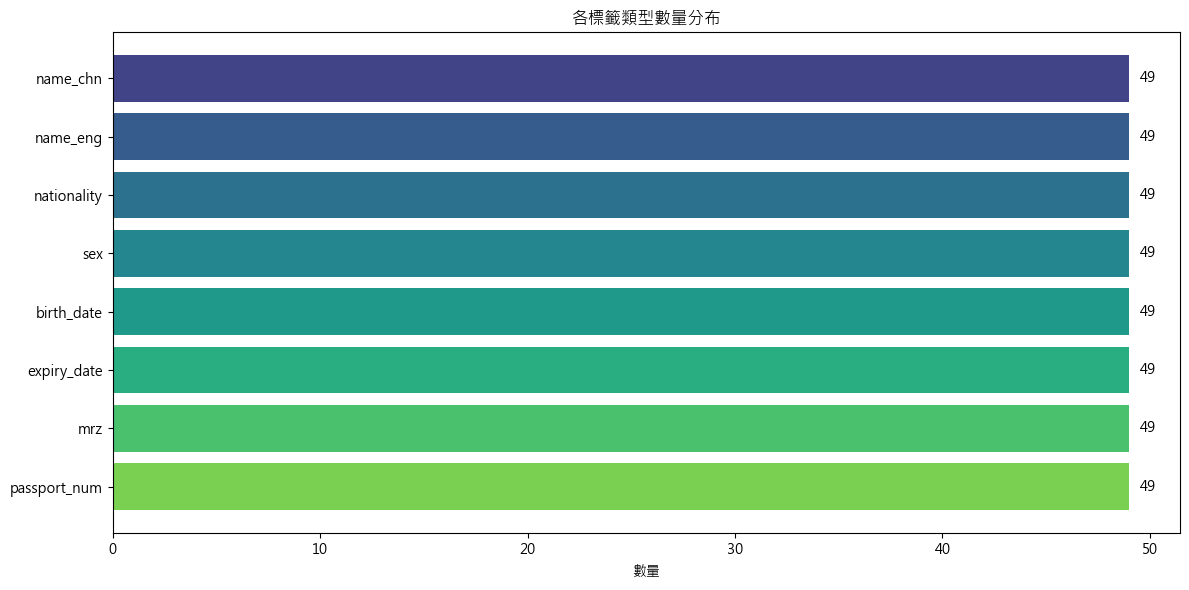

📊 總標註數量: 392


In [18]:
# Cell 2.4: 視覺化標籤分布

fig, ax = plt.subplots(figsize=(12, 6))

labels = list(label_counts.keys())
counts = list(label_counts.values())

# 依照數量排序
sorted_pairs = sorted(zip(labels, counts), key=lambda x: -x[1])
labels, counts = zip(*sorted_pairs)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(labels)))
bars = ax.barh(labels, counts, color=colors)

# 在每個 bar 上顯示數量
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            str(count), va='center', fontsize=10)

ax.set_xlabel('數量')
ax.set_title('各標籤類型數量分布')
ax.invert_yaxis()  # 最多的在上面

plt.tight_layout()
plt.show()

print(f"📊 總標註數量: {sum(counts)}")


In [19]:
# Cell 2.5: 定義圖片 ID 提取函數並檢查對應關係

print("🔍 檢查圖片與標註的對應關係...")

# 取得所有圖片檔名
available_images = set(f.stem for f in IMAGES_DIR.glob("*.jpg"))
print(f"📁 圖片目錄中有 {len(available_images)} 張圖片")

def extract_image_id(item):
    """
    從 Label Studio 項目中提取圖片 ID。
    
    根據用戶說明：圖片名稱與 data.ocr 路徑最後的數字相同
    例如 "data":{"ocr":"/data/upload/2/a744d314-46183.jpg"} → 46183
    
    Args:
        item: Label Studio 標註項目
    
    Returns:
        str: 圖片 ID（不含副檔名）
    """
    if 'data' in item:
        data = item['data']
        # 嘗試從各種可能的欄位提取
        for key in ['ocr', 'image', 'img']:
            if key in data:
                # 提取檔名中的數字部分
                match = re.search(r'(\d+)\.jpg', str(data[key]))
                if match:
                    return match.group(1)
    # 如果找不到，使用 item id
    return str(item.get('id', ''))

# 建立 item id → image id 的對應
item_to_image = {}
matched_count = 0
unmatched_items = []

for item in label_studio_data:
    img_id = extract_image_id(item)
    item_to_image[item['id']] = img_id
    
    if img_id in available_images:
        matched_count += 1
    else:
        unmatched_items.append((item['id'], img_id))

print(f"\n📊 對應結果：")
print(f"  ✅ 成功匹配: {matched_count} 筆")
print(f"  ❌ 未匹配: {len(unmatched_items)} 筆")

if unmatched_items[:5]:
    print(f"\n⚠️ 前 5 筆未匹配的項目：")
    for item_id, img_id in unmatched_items[:5]:
        print(f"  item_id={item_id}, 嘗試的圖片名={img_id}")


🔍 檢查圖片與標註的對應關係...
📁 圖片目錄中有 49 張圖片

📊 對應結果：
  ✅ 成功匹配: 49 筆
  ❌ 未匹配: 0 筆


📸 顯示樣本標註...


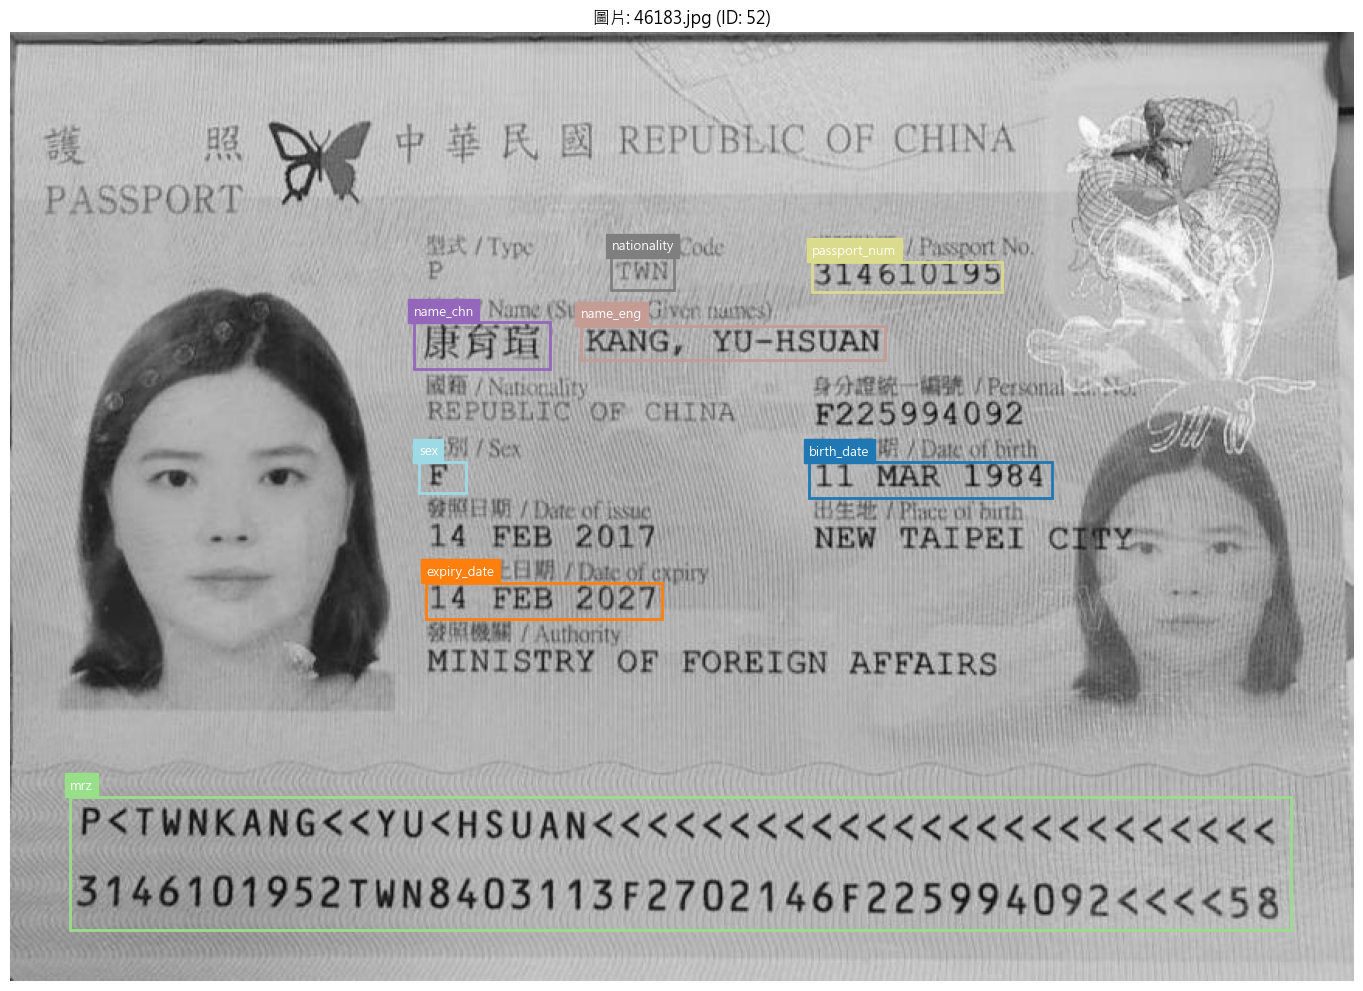

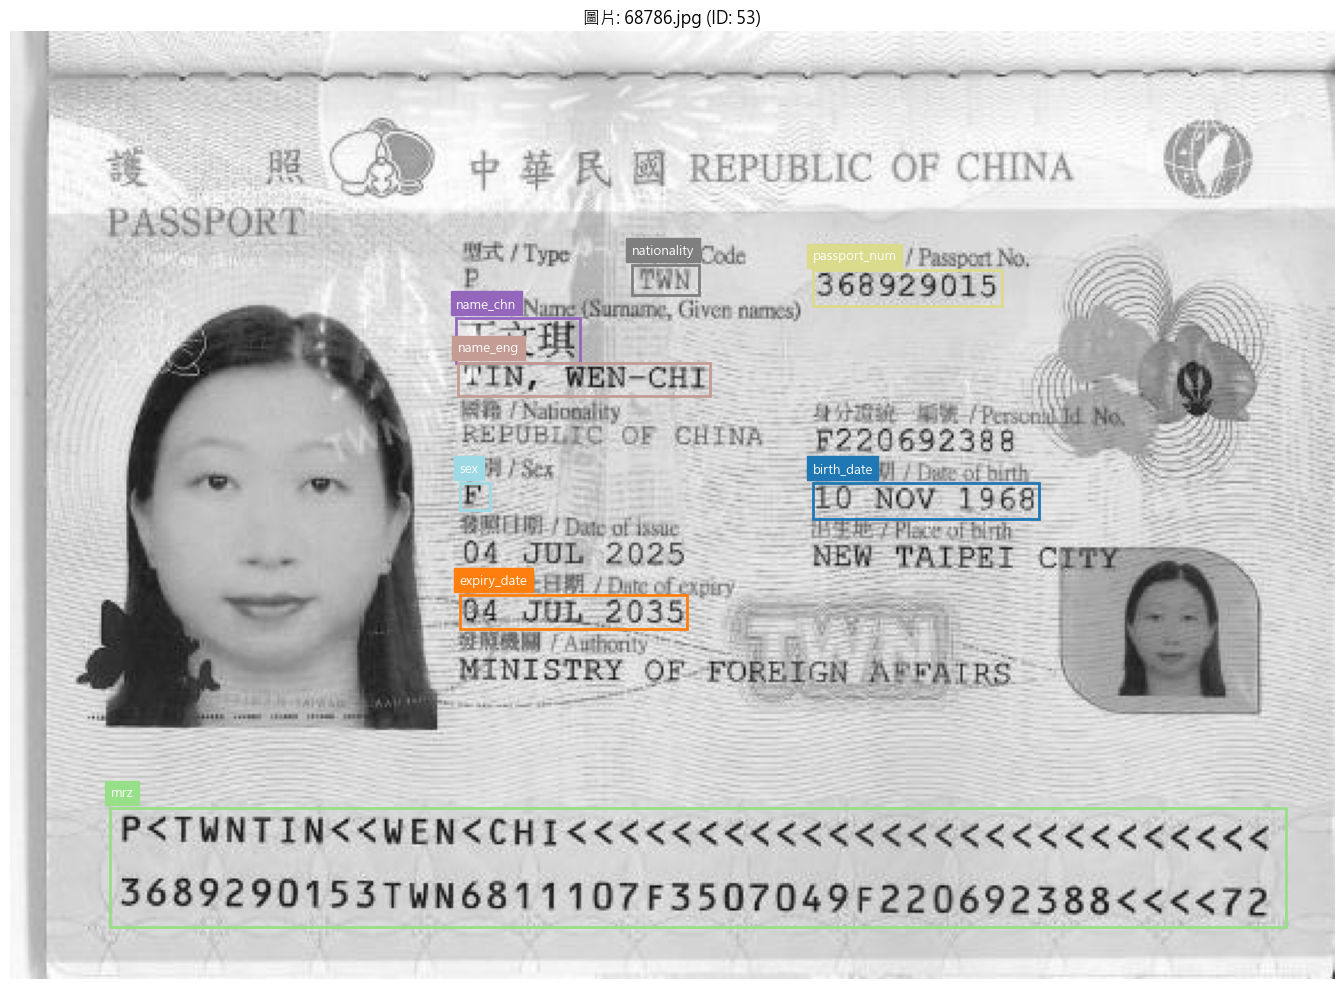

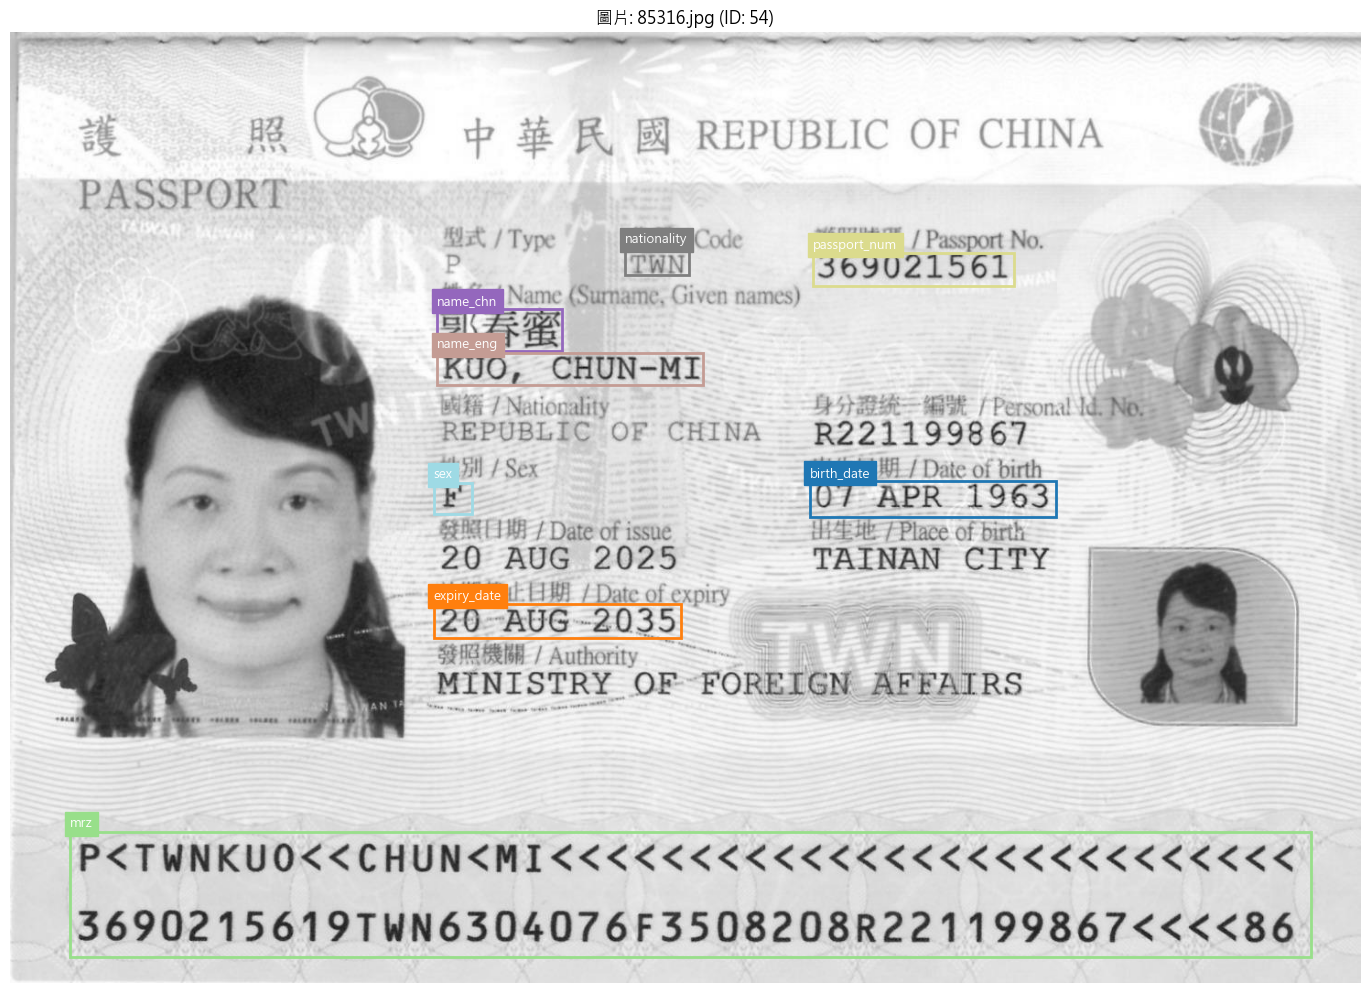

In [20]:
# Cell 2.6: 視覺化樣本標註

def visualize_annotation(item, images_dir, class_to_id):
    """
    視覺化單一項目的標註。
    
    Args:
        item: Label Studio 標註項目
        images_dir: 圖片目錄
        class_to_id: 類別名稱到 ID 的對應
    """
    img_id = extract_image_id(item)
    img_path = images_dir / f"{img_id}.jpg"
    
    if not img_path.exists():
        print(f"⚠️ 找不到圖片: {img_path}")
        return
    
    # 讀取圖片
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    
    # 設定顏色
    colors = plt.cm.tab20(np.linspace(0, 1, len(class_to_id)))
    
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(img)
    
    # 繪製每個標註框
    if 'annotations' in item and item['annotations']:
        for anno in item['annotations']:
            for result in anno.get('result', []):
                if result.get('type') == 'labels' and 'value' in result:
                    value = result['value']
                    labels = value.get('labels', [])
                    
                    if labels:
                        label = labels[0]
                        class_id = class_to_id.get(label, 0)
                        color = colors[class_id % len(colors)]
                        
                        # Label Studio 座標是百分比
                        x = value['x'] / 100 * img_w
                        y = value['y'] / 100 * img_h
                        w = value['width'] / 100 * img_w
                        h = value['height'] / 100 * img_h
                        
                        # 繪製矩形
                        rect = plt.Rectangle((x, y), w, h, 
                                            fill=False, edgecolor=color, linewidth=2)
                        ax.add_patch(rect)
                        
                        # 添加標籤文字
                        ax.text(x, y - 5, label, fontsize=9, 
                               color='white', backgroundcolor=color[:3])
    
    ax.set_title(f'圖片: {img_id}.jpg (ID: {item["id"]})')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# 顯示前 3 張有標註的圖片
print("📸 顯示樣本標註...")
sample_count = 0
for item in label_studio_data:
    img_id = extract_image_id(item)
    if img_id in available_images:
        visualize_annotation(item, IMAGES_DIR, CLASS_TO_ID)
        sample_count += 1
        if sample_count >= 3:
            break


---
## 3. Label Studio JSON → YOLO 格式轉換


In [21]:
# Cell 3.1: 定義 YOLO 格式轉換函數

def convert_to_yolo_format(item, class_to_id):
    """
    將 Label Studio 項目轉換為 YOLO 格式。
    
    Args:
        item: Label Studio 標註項目
        class_to_id: 類別名稱到 ID 的對應字典
    
    Returns:
        list[str]: YOLO 格式的標註行列表
        
    YOLO 格式: class_id center_x center_y width height (全部正規化到 0-1)
    
    Examples:
        >>> lines = convert_to_yolo_format(item, {"name_chn": 0})
        >>> print(lines[0])
        "0 0.350000 0.329000 0.101740 0.049251"
    
    Raises:
        此函數不會拋出錯誤，無效的標註會被跳過
    """
    yolo_lines = []
    
    if 'annotations' not in item or not item['annotations']:
        return yolo_lines
    
    for anno in item['annotations']:
        for result in anno.get('result', []):
            # 只處理 labels 類型（包含類別資訊的框）
            if result.get('type') != 'labels':
                continue
            
            value = result.get('value', {})
            labels = value.get('labels', [])
            
            if not labels:
                continue
            
            label = labels[0]  # 取第一個標籤
            class_id = class_to_id.get(label)
            
            if class_id is None:
                continue
            
            # Label Studio 座標是百分比 (0-100)
            x = value.get('x', 0) / 100
            y = value.get('y', 0) / 100
            w = value.get('width', 0) / 100
            h = value.get('height', 0) / 100
            
            # 轉換為 YOLO 格式 (center_x, center_y, width, height)
            center_x = x + w / 2
            center_y = y + h / 2
            
            # 確保值在 0-1 範圍內
            center_x = max(0, min(1, center_x))
            center_y = max(0, min(1, center_y))
            w = max(0, min(1, w))
            h = max(0, min(1, h))
            
            yolo_line = f"{class_id} {center_x:.6f} {center_y:.6f} {w:.6f} {h:.6f}"
            yolo_lines.append(yolo_line)
    
    return yolo_lines

print("✅ YOLO 格式轉換函數定義完成")

# 測試轉換
print("\n🧪 測試轉換第一筆資料：")
test_lines = convert_to_yolo_format(label_studio_data[0], CLASS_TO_ID)
for line in test_lines[:5]:
    print(f"  {line}")
if len(test_lines) > 5:
    print(f"  ... 共 {len(test_lines)} 行")


✅ YOLO 格式轉換函數定義完成

🧪 測試轉換第一筆資料：
  3 0.350736 0.329606 0.101740 0.049251
  4 0.537483 0.326765 0.226238 0.035991
  5 0.470549 0.253835 0.046854 0.034097
  7 0.321285 0.468836 0.034806 0.032203
  0 0.684739 0.471678 0.180723 0.037886
  ... 共 8 行


In [22]:
# Cell 3.2: 建立 YOLO 資料集目錄結構

print("📁 建立 YOLO 資料集目錄結構...")

# 定義目錄結構
dirs_to_create = [
    DATASET_DIR / "images" / "train",
    DATASET_DIR / "images" / "val",
    DATASET_DIR / "images" / "test",
    DATASET_DIR / "labels" / "train",
    DATASET_DIR / "labels" / "val",
    DATASET_DIR / "labels" / "test",
]

for dir_path in dirs_to_create:
    dir_path.mkdir(parents=True, exist_ok=True)
    print(f"  ✅ {dir_path.relative_to(PROJECT_ROOT)}")

print("\n✅ 目錄結構建立完成！")


📁 建立 YOLO 資料集目錄結構...
  ✅ dataset\images\train
  ✅ dataset\images\val
  ✅ dataset\images\test
  ✅ dataset\labels\train
  ✅ dataset\labels\val
  ✅ dataset\labels\test

✅ 目錄結構建立完成！


In [23]:
# Cell 3.3: 收集有效資料並分割資料集

# 設定分割比例
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

print(f"📊 資料集分割比例: Train={TRAIN_RATIO}, Val={VAL_RATIO}, Test={TEST_RATIO}")

# 收集所有有效的資料
valid_items = []

for item in tqdm(label_studio_data, desc="收集有效資料"):
    img_id = extract_image_id(item)
    if img_id in available_images:
        yolo_lines = convert_to_yolo_format(item, CLASS_TO_ID)
        if yolo_lines:  # 只保留有標註的項目
            valid_items.append({
                'img_id': img_id,
                'yolo_lines': yolo_lines
            })

print(f"\n📋 有效資料: {len(valid_items)} 筆")

# 隨機打亂
random.seed(42)  # 固定種子以確保可重現
random.shuffle(valid_items)

# 計算分割點
n_total = len(valid_items)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)

train_items = valid_items[:n_train]
val_items = valid_items[n_train:n_train + n_val]
test_items = valid_items[n_train + n_val:]

print(f"\n📊 分割結果：")
print(f"  Train: {len(train_items)} 張")
print(f"  Val: {len(val_items)} 張")
print(f"  Test: {len(test_items)} 張")


📊 資料集分割比例: Train=0.7, Val=0.2, Test=0.1


收集有效資料:   0%|          | 0/49 [00:00<?, ?it/s]


📋 有效資料: 49 筆

📊 分割結果：
  Train: 34 張
  Val: 9 張
  Test: 6 張


In [24]:
# Cell 3.4: 複製圖片並產生標籤檔案

def process_split(items, split_name):
    """
    處理資料集分割，複製圖片並產生 YOLO 標籤檔。
    
    Args:
        items: 資料項目列表
        split_name: 分割名稱 (train/val/test)
    
    Examples:
        >>> process_split(train_items, 'train')
    
    Raises:
        此函數不會拋出錯誤，個別檔案的錯誤會被跳過並顯示警告
    """
    images_dst = DATASET_DIR / "images" / split_name
    labels_dst = DATASET_DIR / "labels" / split_name
    
    for item in tqdm(items, desc=f"處理 {split_name}"):
        img_id = item['img_id']
        
        # 複製圖片
        src_path = IMAGES_DIR / f"{img_id}.jpg"
        dst_path = images_dst / f"{img_id}.jpg"
        
        if not dst_path.exists():
            shutil.copy2(src_path, dst_path)
        
        # 產生標籤檔
        label_path = labels_dst / f"{img_id}.txt"
        with open(label_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(item['yolo_lines']))

print("⏳ 開始處理資料集...")

process_split(train_items, 'train')
process_split(val_items, 'val')
process_split(test_items, 'test')

print("\n✅ 所有資料處理完成！")


⏳ 開始處理資料集...


處理 train:   0%|          | 0/34 [00:00<?, ?it/s]

處理 val:   0%|          | 0/9 [00:00<?, ?it/s]

處理 test:   0%|          | 0/6 [00:00<?, ?it/s]


✅ 所有資料處理完成！


In [25]:
# Cell 3.5: 產生 data.yaml 設定檔

data_yaml = {
    'path': str(DATASET_DIR.resolve()),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(CLASS_NAMES),
    'names': {i: name for i, name in enumerate(CLASS_NAMES)}
}

yaml_path = DATASET_DIR / 'data.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print("✅ data.yaml 產生完成！")
print(f"📁 路徑: {yaml_path}")
print("\n📋 內容：")
print("="*50)
with open(yaml_path, 'r', encoding='utf-8') as f:
    print(f.read())


✅ data.yaml 產生完成！
📁 路徑: C:\Users\wu020\Documents\Passport-image-recognition\dataset\data.yaml

📋 內容：
names:
  0: birth_date
  1: expiry_date
  2: mrz
  3: name_chn
  4: name_eng
  5: nationality
  6: passport_num
  7: sex
nc: 8
path: C:\Users\wu020\Documents\Passport-image-recognition\dataset
test: images/test
train: images/train
val: images/val



In [26]:
# Cell 3.6: 驗證資料集

print("🔍 驗證資料集...")

for split in ['train', 'val', 'test']:
    images = list((DATASET_DIR / 'images' / split).glob('*.jpg'))
    labels = list((DATASET_DIR / 'labels' / split).glob('*.txt'))
    
    print(f"\n{split}:")
    print(f"  圖片數量: {len(images)}")
    print(f"  標籤數量: {len(labels)}")
    
    # 檢查是否每張圖片都有對應的標籤
    image_stems = set(img.stem for img in images)
    label_stems = set(lbl.stem for lbl in labels)
    
    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems
    
    if missing_labels:
        print(f"  ⚠️ 缺少標籤: {len(missing_labels)} 張")
    if missing_images:
        print(f"  ⚠️ 缺少圖片: {len(missing_images)} 張")
    if not missing_labels and not missing_images:
        print(f"  ✅ 圖片與標籤完全匹配")

print("\n✅ 資料集驗證完成！")


🔍 驗證資料集...

train:
  圖片數量: 111
  標籤數量: 111
  ✅ 圖片與標籤完全匹配

val:
  圖片數量: 29
  標籤數量: 29
  ✅ 圖片與標籤完全匹配

test:
  圖片數量: 6
  標籤數量: 6
  ✅ 圖片與標籤完全匹配

✅ 資料集驗證完成！


---
## 4. YOLOv11 模型訓練


In [63]:
# Cell 4.1: 載入 YOLO 模型

from ultralytics import YOLO

print("⏳ 載入 YOLOv11 模型...")

# 使用 YOLOv11m (medium) - 平衡速度與精度
# 可選: yolo11n.pt (nano, 最快), yolo11s.pt (small), yolo11m.pt (medium), yolo11l.pt (large)
MODEL_NAME = 'yolo11m.pt'

model = YOLO(MODEL_NAME)

print(f"✅ 模型 {MODEL_NAME} 載入完成！")
print(f"📊 模型類型: {type(model).__name__}")


⏳ 載入 YOLOv11 模型...
✅ 模型 yolo11m.pt 載入完成！
📊 模型類型: YOLO


In [64]:
# Cell 4.2: 設定訓練參數

# 訓練設定
TRAIN_CONFIG = {
    'data': str(DATASET_DIR / 'data.yaml'),
    'epochs': 30,              # 訓練輪數
    'imgsz': 640,              # 輸入圖片大小
    'batch': 8,                # 批次大小（根據 GPU 記憶體調整）
    'patience': 20,            # Early stopping 耐心值
    'save': True,              # 儲存模型
    'device': 'cpu',               # GPU device (0) 或 'cpu'
    'workers': 4,              # 資料載入 workers
    'project': str(PROJECT_ROOT / 'runs' / 'detect'),
    'name': 'passport_fields',
    'exist_ok': True,          # 允許覆蓋現有資料夾
    'pretrained': True,        # 使用預訓練權重
    'optimizer': 'auto',       # 優化器
    'verbose': True,           # 詳細輸出
    'seed': 42,                # 隨機種子
}

print("📋 訓練設定：")
print("="*50)
for key, value in TRAIN_CONFIG.items():
    print(f"  {key}: {value}")


📋 訓練設定：
  data: C:\Users\wu020\Documents\Passport-image-recognition\dataset\data.yaml
  epochs: 30
  imgsz: 640
  batch: 8
  patience: 20
  save: True
  device: cpu
  workers: 4
  project: C:\Users\wu020\Documents\Passport-image-recognition\runs\detect
  name: passport_fields
  exist_ok: True
  pretrained: True
  optimizer: auto
  verbose: True
  seed: 42


In [65]:
# Cell 4.3: 開始訓練

print("🚀 開始訓練模型...")
print(f"📅 開始時間: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*50)

# 執行訓練
results = model.train(**TRAIN_CONFIG)

print("="*50)
print(f"✅ 訓練完成！")
print(f"📅 結束時間: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📁 模型儲存位置: {results.save_dir}")


🚀 開始訓練模型...
📅 開始時間: 2025-12-18 14:44:06
New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.239  Python-3.10.11 torch-2.9.1+cpu CPU (AMD Ryzen 9 5900HS with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\wu020\Documents\Passport-image-recognition\dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.

In [11]:
# Cell 4.4: 視覺化訓練結果

# 載入訓練結果圖表
results_dir = Path(results.save_dir)

print("📊 訓練結果視覺化：")

# 顯示訓練曲線
results_png = results_dir / 'results.png'
if results_png.exists():
    img = plt.imread(str(results_png))
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('訓練曲線')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 找不到 results.png")

# 顯示混淆矩陣
confusion_matrix_png = results_dir / 'confusion_matrix.png'
if confusion_matrix_png.exists():
    img = plt.imread(str(confusion_matrix_png))
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('混淆矩陣')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 找不到 confusion_matrix.png")


NameError: name 'results' is not defined

---
## 5. 模型評估


In [29]:
# Cell 5.1: 載入最佳模型

best_model_path = results_dir / 'weights' / 'best.pt'

if best_model_path.exists():
    best_model = YOLO(str(best_model_path))
    print(f"✅ 最佳模型載入完成: {best_model_path}")
else:
    print(f"⚠️ 找不到最佳模型，使用最後一個模型")
    last_model_path = results_dir / 'weights' / 'last.pt'
    best_model = YOLO(str(last_model_path))


NameError: name 'results_dir' is not defined

In [71]:
# Cell 5.2: 在測試集上評估

print("🧪 在測試集上評估模型...")

eval_results = best_model.val(
    data=str(DATASET_DIR / 'data.yaml'),
    split='test',
    verbose=True
)

print("\n📊 評估指標：")
print(f"  mAP@0.5: {eval_results.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {eval_results.box.map:.4f}")
print(f"  Precision: {eval_results.box.mp:.4f}")
print(f"  Recall: {eval_results.box.mr:.4f}")


🧪 在測試集上評估模型...
Ultralytics 8.3.239  Python-3.10.11 torch-2.9.1+cpu CPU (AMD Ryzen 9 5900HS with Radeon Graphics)
YOLO11m summary (fused): 125 layers, 20,036,200 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 85.063.3 MB/s, size: 216.1 KB)
val: Scanning C:\Users\wu020\Documents\Passport-image-recognition\dataset\labels\test.cache... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6 3.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9s/it 1.9s
                   all          6         48      0.986          1      0.995      0.776
            birth_date          6          6      0.985          1      0.995      0.897
           expiry_date          6          6       0.98          1      0.995      0.818
                   mrz          6          6      0.988          1      0.995      0.803
              name_chn          6          6      0.975          1      0.9

📸 視覺化測試集預測結果...


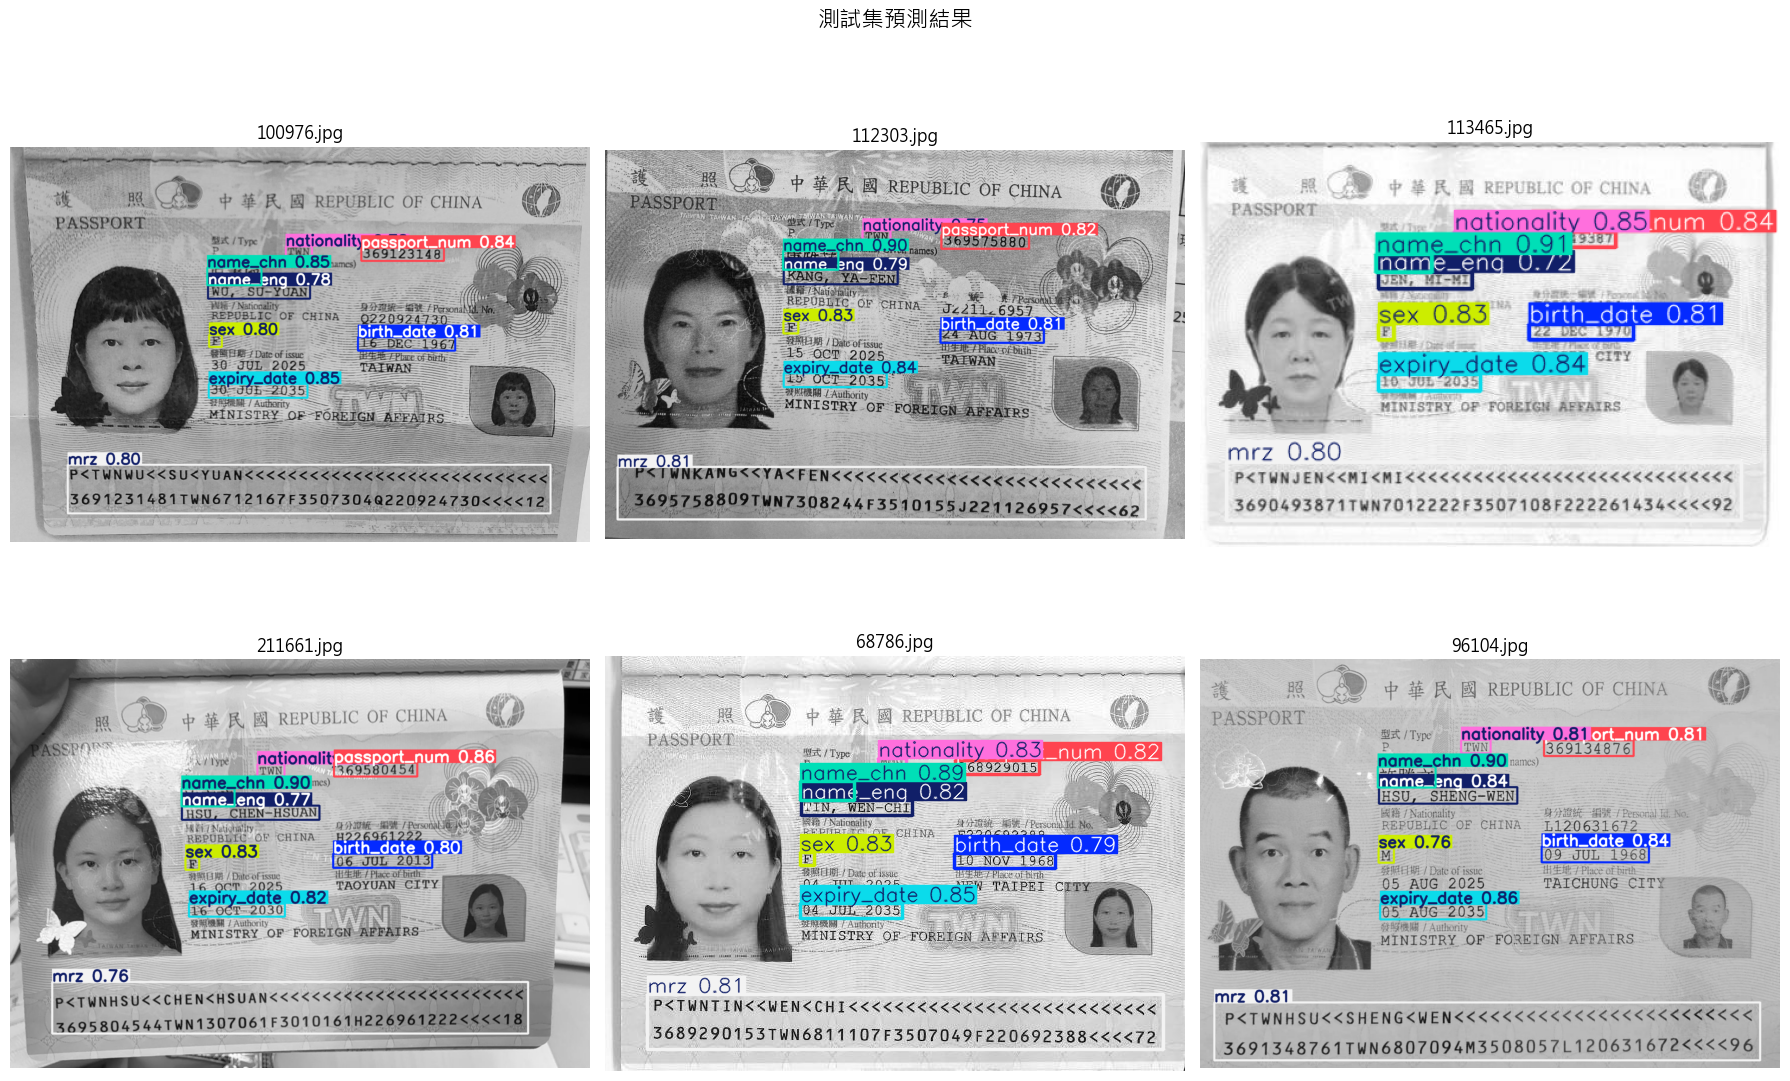

In [72]:
# Cell 5.3: 視覺化預測結果

print("📸 視覺化測試集預測結果...")

test_images = list((DATASET_DIR / 'images' / 'test').glob('*.jpg'))[:6]

if test_images:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for ax, img_path in zip(axes, test_images):
        # 執行預測
        pred_results = best_model.predict(str(img_path), verbose=False)
        
        # 取得標註後的圖片
        annotated_img = pred_results[0].plot()
        annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        
        ax.imshow(annotated_img)
        ax.set_title(img_path.name)
        ax.axis('off')

    plt.suptitle('測試集預測結果', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 測試集中沒有圖片")


---
## 6. PaddleOCR 整合


In [31]:
# from pathlib import Path
# from ultralytics import YOLO

# # 硬編碼：請確認 runs/detect/passport_fields/weights/ 內是否有 best.pt / last.pt
# best_model_path = Path(r"C:\Users\wu020\Documents\Passport-image-recognition\runs\detect\passport_fields\weights\best.pt")
# last_model_path = Path(r"C:\Users\wu020\Documents\Passport-image-recognition\runs\detect\passport_fields\weights\last.pt")

# if best_model_path.exists():
#     best_model = YOLO(str(best_model_path))
#     print(f"✅ 最佳模型載入完成: {best_model_path}")
# elif last_model_path.exists():
#     best_model = YOLO(str(last_model_path))
#     print(f"⚠️ 找不到 best.pt，改載入 last.pt: {last_model_path}")
# else:
#     raise FileNotFoundError(
#         "❌ 找不到 best.pt / last.pt，請確認訓練輸出資料夾是否存在：\n"
#         "runs/detect/passport_fields/weights/"
#     )

✅ 最佳模型載入完成: C:\Users\wu020\Documents\Passport-image-recognition\runs\detect\passport_fields\weights\best.pt


In [32]:
# Cell 6.1: 初始化 PaddleOCR

from paddleocr import PaddleOCR

print("⏳ 初始化 PaddleOCR...")

# # 初始化 OCR 識別器 這是 GPU版本
# ocr = PaddleOCR(
#     use_angle_cls=True,    # 使用文字方向分類
#     lang='ch',             # 中文模型（同時支援英文）
#     use_gpu=True,          # 使用 GPU
#     show_log=False         # 關閉日誌
# )


# 初始化 OCR 識別器
ocr = PaddleOCR(
    use_textline_orientation=True,  # 使用文字方向分類（取代 use_angle_cls）
    lang='ch',                       # 中文模型（同時支援英文）
    device='cpu'                     # 使用 CPU（如果沒有 GPU，改為 'cpu'）
)

print("✅ PaddleOCR 初始化完成！")


Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wu020\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.


⏳ 初始化 PaddleOCR...


Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wu020\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wu020\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wu020\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wu020\.paddlex\official_models\PP-OCRv5_server_rec`.


✅ PaddleOCR 初始化完成！


In [71]:
import cv2
import numpy as np

# 欄位類型分類
FIELD_TYPES = {
    'mrz': 'mrz',
    'passport_num': 'numeric',
    'birth_date': 'date',
    'expiry_date': 'date',
    'sex': 'single_char',
    'nationality': 'short_text',
    'name_chn': 'chinese',
    'name_eng': 'english',
}

def get_preprocess_config(field_name: str) -> dict:
    """
    根據欄位名稱回傳對應的前處理參數。

    Args:
        field_name (str): 欄位名稱（如 'mrz', 'name_chn'）

    Returns:
        dict: 前處理參數字典

    Examples:
        >>> config = get_preprocess_config('mrz')
        >>> config['use_binarize']
        True

    Raises:
        KeyError: 當欄位名稱不在 FIELD_TYPES 中時（會回傳預設值，不會真的拋錯）
    """
    field_type = FIELD_TYPES.get(field_name, 'default')

    configs = {
            'mrz': {
                'target_min_height': 80,      # ⬆️ 放大一點
                'use_clahe': True,
                'denoise_strength': 5,        # ⬇️ 減少去噪，保留細節
                'sharpen': True,
                'use_binarize': False,        # ❌ 關掉二值化，避免底紋干擾
            },
            'numeric': {
                'target_min_height': 64,      # ⬆️ 放大
                'use_clahe': True,
                'denoise_strength': 6,        # ⬇️ 減少去噪
                'sharpen': True,
                'use_binarize': False,
            },
            'date': {
                'target_min_height': 72,      # ⬆️ 放大（月份英文需要更清楚）
                'use_clahe': True,
                'denoise_strength': 6,        # ⬇️ 減少去噪
                'sharpen': True,
                'use_binarize': False,
            },
            'single_char': {
                'target_min_height': 128,     # ⬆️⬆️ 大幅放大（單字元最需要）
                'use_clahe': True,
                'denoise_strength': 0,        # ❌ 完全不去噪（保留所有細節）
                'sharpen': True,
                'use_binarize': False,
            },
            'chinese': {
                'target_min_height': 64,      # 維持
                'use_clahe': True,
                'denoise_strength': 6,        # ⬇️ 稍微減少
                'sharpen': False,             # 維持不銳化
                'use_binarize': False,
            },
            'english': {
                'target_min_height': 64,      # ⬆️ 放大
                'use_clahe': True,
                'denoise_strength': 6,        # ⬇️ 減少去噪
                'sharpen': True,
                'use_binarize': False,
            },
            'short_text': {
                'target_min_height': 80,      # ⬆️ 放大（nationality 等）
                'use_clahe': True,
                'denoise_strength': 5,        # ⬇️ 減少去噪
                'sharpen': True,
                'use_binarize': False,
            },
            'default': {
                'target_min_height': 56,
                'use_clahe': True,
                'denoise_strength': 8,
                'sharpen': True,
                'use_binarize': False,
            },
        }


    return configs.get(field_type, configs['default'])


def preprocess_roi_for_ocr(
    roi: np.ndarray,
    *,
    target_min_height: int = 48,
    use_clahe: bool = True,
    denoise_strength: int = 10,
    sharpen: bool = True,
    use_binarize: bool = False
) -> np.ndarray:
    """
    對裁切出的 ROI 做 OCR 前處理（依欄位類型調整）。

    Args:
        roi (np.ndarray): 裁切後的影像區塊（BGR 或灰階）。
        target_min_height (int): ROI 高度小於此值時進行放大。
        use_clahe (bool): 是否使用 CLAHE 進行局部對比增強。
        denoise_strength (int): 去噪強度。
        sharpen (bool): 是否做輕量銳化。
        use_binarize (bool): 是否做自適應二值化（僅 MRZ/數字欄位建議開）。

    Returns:
        np.ndarray: 前處理後的 ROI（灰階）。

    Examples:
        >>> roi2 = preprocess_roi_for_ocr(roi, target_min_height=64, use_binarize=True)
        >>> roi2.dtype
        dtype('uint8')

    Raises:
        ValueError: 當 roi 為空或尺寸不合法時。
        TypeError: 當 roi 不是 np.ndarray 時。
    """
    if not isinstance(roi, np.ndarray):
        raise TypeError("roi 必須是 np.ndarray")
    if roi.size == 0 or roi.shape[0] < 2 or roi.shape[1] < 2:
        raise ValueError("roi 為空或尺寸不合法")

    # 灰階化
    if roi.ndim == 3:
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    else:
        gray = roi.copy()

    # 放大小 ROI
    h, w = gray.shape[:2]
    if h < target_min_height:
        scale = target_min_height / float(h)
        new_w = max(2, int(round(w * scale)))
        new_h = max(2, int(round(h * scale)))
        gray = cv2.resize(gray, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

    # CLAHE 對比增強
    if use_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray = clahe.apply(gray)

    # 去噪
    if denoise_strength > 0:
        gray = cv2.fastNlMeansDenoising(gray, h=denoise_strength, templateWindowSize=7, searchWindowSize=21)

    # 銳化
    if sharpen:
        blur = cv2.GaussianBlur(gray, (0, 0), sigmaX=1.0)
        gray = cv2.addWeighted(gray, 1.5, blur, -0.5, 0)

    # 二值化（僅 MRZ 或純數字欄位）
    if use_binarize:
        gray = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 4
        )

    # 轉回 3 通道 BGR，讓 PaddleOCR 能正常處理
    bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    return bgr

In [90]:
# Cell 6.2: 定義完整的處理 Pipeline（優化版）

def process_passport_image(image_path, detector, recognizer, conf_threshold=0.5, 
                           min_box_area=100, use_nms_per_class=True):
    """
    處理護照圖片：偵測欄位 + OCR 識別。
    
    Args:
        image_path: 圖片路徑
        detector: YOLO 偵測模型
        recognizer: PaddleOCR 識別器
        conf_threshold: 信心度閾值（建議提高到 0.6-0.7）
        min_box_area: 最小框面積（過濾太小的框）
        use_nms_per_class: 是否對每個類別進行 NMS（非極大值抑制）
    
    Returns:
        dict: 包含欄位名稱和識別結果的字典
    
    Examples:
        >>> result = process_passport_image("passport.jpg", model, ocr, conf_threshold=0.7)
        >>> print(result['fields']['name_chn']['text'])
        "王小明"
    
    Raises:
        ValueError: 當圖片無法讀取時
    """
    import time
    import numpy as np
    from collections import defaultdict
    
    start_time = time.time()
    
    # 讀取圖片
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"無法讀取圖片: {image_path}")
    
    # 1. YOLO 偵測（提高信心度閾值以減少誤檢）
    detect_results = detector.predict(str(image_path), conf=conf_threshold, verbose=False)
    detections = detect_results[0].boxes
    
    # 取得類別名稱
    class_names = detector.names
    
    # 2. 過濾和優化偵測框
    filtered_detections = []
    
    for box in detections:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        class_id = int(box.cls[0])
        conf = float(box.conf[0])
        
        # 計算框面積
        box_area = (x2 - x1) * (y2 - y1)
        
        # 過濾太小的框
        if box_area < min_box_area:
            continue
        
        filtered_detections.append({
            'box': box,
            'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
            'class_id': class_id,
            'conf': conf,
            'area': box_area
        })
    
    # 3. 對每個類別進行 NMS（保留信心度最高的框）
    if use_nms_per_class:
        class_detections = defaultdict(list)
        for det in filtered_detections:
            class_detections[det['class_id']].append(det)
        
        # 對每個類別，只保留信心度最高的框（或使用 IoU 進行 NMS）
        final_detections = []
        for class_id, dets in class_detections.items():
            # 按信心度排序
            dets_sorted = sorted(dets, key=lambda x: x['conf'], reverse=True)
            
            # 簡單策略：只保留每個類別信心度最高的框
            # 或者可以實現更複雜的 IoU-based NMS
            final_detections.append(dets_sorted[0])
            
            # 可選：如果有多個高信心度的框且不重疊，也可以保留
            # 這裡先只保留最高信心度的框
    else:
        final_detections = filtered_detections
    
    # 4. 對過濾後的偵測框進行 OCR
    extracted_fields = {}
    seen_classes = set()
    
    for idx, det in enumerate(final_detections):
        x1, y1, x2, y2 = det['x1'], det['y1'], det['x2'], det['y2']
        class_id = det['class_id']
        conf = det['conf']
        class_name = class_names.get(class_id, f'class_{class_id}')
        
        # 加入邊界以改進 OCR
        margin = 5
        x1 = max(0, x1 - margin)
        y1 = max(0, y1 - margin)
        x2 = min(img.shape[1], x2 + margin)
        y2 = min(img.shape[0], y2 + margin)
        
        # 裁切 ROI
        roi = img[y1:y2, x1:x2]
        
        # 檢查 ROI 是否太小
        if roi.size == 0 or roi.shape[0] < 10 or roi.shape[1] < 10:
            continue

        # 根據欄位類型取得對應參數
        preprocess_config = get_preprocess_config(class_name)

        try:
            roi_for_ocr = preprocess_roi_for_ocr(roi, **preprocess_config)
        except (ValueError, TypeError) as e:
            print(f"⚠️ ROI 前處理失敗 ({class_name}): {e}")
            continue
        
        # OCR 識別
        try:
            ocr_results = recognizer.predict(roi_for_ocr)
            
            texts = []
            confidences = []
            
            if ocr_results and len(ocr_results) > 0:
                result = ocr_results[0]
                
                # 從 json 屬性中提取文字和信心度
                json_data = result.json
                
                if 'res' in json_data:
                    res = json_data['res']
                    
                    if 'rec_texts' in res and 'rec_scores' in res:
                        rec_texts = res['rec_texts']
                        rec_scores = res['rec_scores']
                        
                        # 過濾空字串和低信心度的結果
                        for text, score in zip(rec_texts, rec_scores):
                            if text and text.strip() and score > 0.3:  # 過濾低信心度
                                texts.append(text.strip())
                                confidences.append(float(score))
            
            text = ' '.join(texts) if texts else ""
            ocr_conf = float(np.mean(confidences)) if confidences else 0.0
            
        except Exception as e:
            print(f"⚠️ OCR 錯誤 ({class_name}): {e}")
            text = ""
            ocr_conf = 0.0
        
        # 處理重複的類別名稱
        if class_name in seen_classes:
            field_key = f"{class_name}_{idx}"
        else:
            field_key = class_name
            seen_classes.add(class_name)
        
        # 儲存結果
        extracted_fields[field_key] = {
            'class': class_name,
            'text': text,
            'bbox': [x1, y1, x2, y2],
            'detection_conf': conf,
            'ocr_conf': ocr_conf
        }
    
    inference_time = (time.time() - start_time) * 1000
    
    return {
        'fields': extracted_fields,
        'inference_time_ms': round(inference_time, 2),
        'num_detections': len(final_detections)
    }

print("✅ 處理 Pipeline 定義完成（已優化）")

✅ 處理 Pipeline 定義完成（已優化）


In [91]:
# Cell 6.3: 測試完整 Pipeline

print("🧪 測試完整 Pipeline...")

# 選擇一張測試圖片
test_images_list = list((DATASET_DIR / 'images' / 'test').glob('*.jpg'))

if test_images_list:
    test_img = test_images_list[0]
    print(f"\n📸 測試圖片: {test_img.name}")
    
    # 執行處理
    result = process_passport_image(test_img, best_model, ocr)
    
    print(f"\n⏱️ 處理時間: {result['inference_time_ms']} ms")
    print(f"📦 偵測到 {result['num_detections']} 個欄位")
    print("\n📋 識別結果：")
    print("="*60)
    
    for field_name, field_info in result['fields'].items():
        print(f"\n【{field_info['class']}】")
        print(f"  文字: {field_info['text']}")
        print(f"  偵測信心度: {field_info['detection_conf']:.2%}")
        print(f"  OCR 信心度: {field_info['ocr_conf']:.2%}")
else:
    print("⚠️ 測試集中沒有圖片")


🧪 測試完整 Pipeline...

📸 測試圖片: 100976.jpg

⏱️ 處理時間: 16493.09 ms
📦 偵測到 8 個欄位

📋 識別結果：

【name_chn】
  文字: 吴素好
  偵測信心度: 85.31%
  OCR 信心度: 68.44%

【expiry_date】
  文字: T9
  偵測信心度: 84.85%
  OCR 信心度: 51.13%

【passport_num】
  文字: 69123148
  偵測信心度: 84.15%
  OCR 信心度: 97.82%

【birth_date】
  文字: DE
  偵測信心度: 81.03%
  OCR 信心度: 99.34%

【sex】
  文字: 
  偵測信心度: 80.34%
  OCR 信心度: 0.00%

【mrz】
  文字: NDSXS 231481TWN6712167F3507304Q22D924730<
  偵測信心度: 80.23%
  OCR 信心度: 69.41%

【name_eng】
  文字: SU-YUAN
  偵測信心度: 78.09%
  OCR 信心度: 97.83%

【nationality】
  文字: 
  偵測信心度: 77.90%
  OCR 信心度: 0.00%


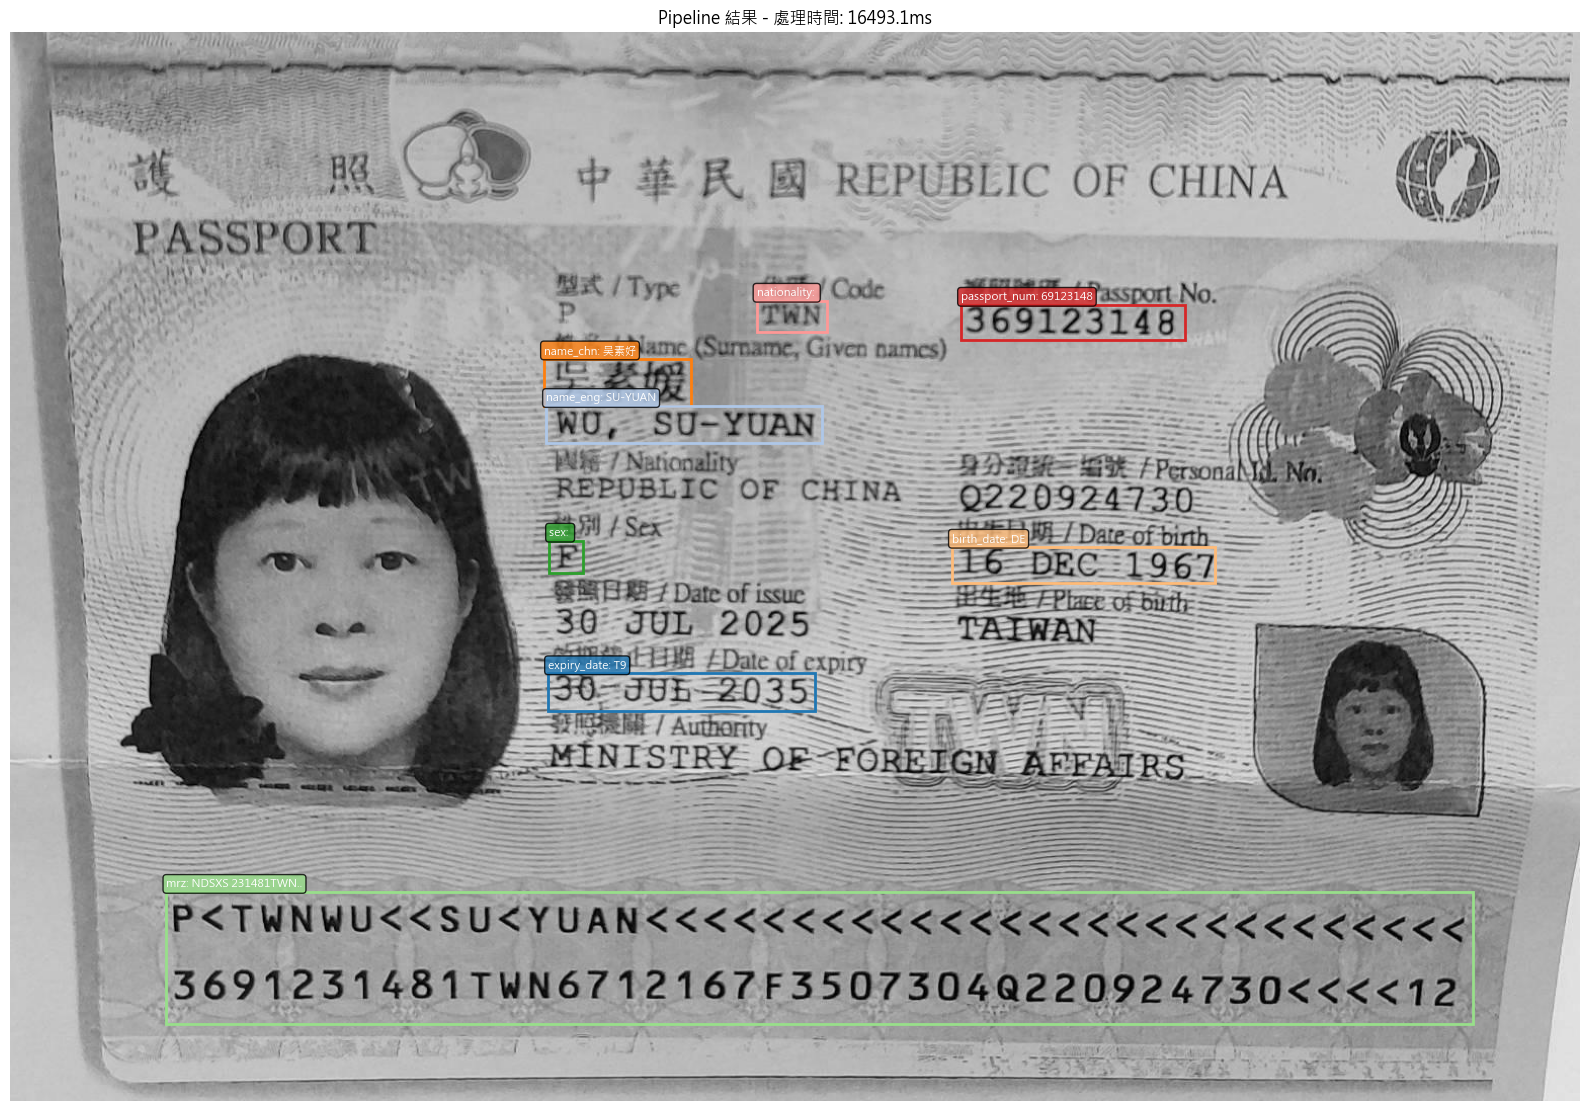

In [92]:
# Cell 6.4: 視覺化 Pipeline 結果

def visualize_pipeline_result(image_path, result, detector):
    """
    視覺化處理結果。
    
    Args:
        image_path: 原始圖片路徑
        result: process_passport_image 的輸出
        detector: YOLO 模型（用於取得類別名稱）
    
    Examples:
        >>> visualize_pipeline_result("test.jpg", result, model)
    
    Raises:
        此函數不會拋出錯誤
    """
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.imshow(img)
    
    # 設定顏色
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    class_names_list = list(set(f['class'] for f in result['fields'].values()))
    color_map = {name: colors[i % len(colors)] for i, name in enumerate(class_names_list)}
    
    for field_name, field_info in result['fields'].items():
        x1, y1, x2, y2 = field_info['bbox']
        color = color_map[field_info['class']]
        
        # 繪製框
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                             fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        
        # 標籤文字
        text_display = field_info['text'][:15] + '..' if len(field_info['text']) > 15 else field_info['text']
        label = f"{field_info['class']}: {text_display}"
        ax.text(x1, y1-5, label, fontsize=8, color='white',
               bbox=dict(boxstyle='round', facecolor=color[:3], alpha=0.8))
    
    ax.set_title(f"Pipeline 結果 - 處理時間: {result['inference_time_ms']:.1f}ms")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# 視覺化
if test_images_list:
    visualize_pipeline_result(test_img, result, best_model)


In [93]:
# Cell 6.5: 提取 Ground Truth 資料

def extract_ground_truth(item):
    """
    從 Label Studio 標註項目中提取 Ground Truth 文字。
    
    Args:
        item: Label Studio 標註項目
    
    Returns:
        dict: {欄位類別: Ground Truth 文字} 的對應字典
    
    Examples:
        >>> gt = extract_ground_truth(label_studio_data[0])
        >>> print(gt)
        {'name_chn': '王小明', 'name_eng': 'WANG, XIAO-MING', ...}
    
    Raises:
        此函數不會拋出錯誤，無效的標註會被跳過
    """
    ground_truth = {}
    
    if 'annotations' not in item or not item['annotations']:
        return ground_truth
    
    # 建立 id 到標籤的對應
    id_to_label = {}
    id_to_text = {}
    
    for anno in item['annotations']:
        for result in anno.get('result', []):
            result_id = result.get('id')
            
            if result.get('type') == 'labels' and 'value' in result:
                labels = result['value'].get('labels', [])
                if labels:
                    id_to_label[result_id] = labels[0]
            
            elif result.get('type') == 'textarea' and 'value' in result:
                text_list = result['value'].get('text', [])
                if text_list:
                    # text 是一個列表，取第一個元素
                    id_to_text[result_id] = text_list[0] if isinstance(text_list, list) else text_list
    
    # 將相同 id 的標籤和文字配對
    for result_id, label in id_to_label.items():
        if result_id in id_to_text:
            ground_truth[label] = id_to_text[result_id]
    
    return ground_truth

# 建立圖片 ID 到 Ground Truth 的對應表
image_ground_truths = {}

for item in tqdm(label_studio_data, desc="提取 Ground Truth"):
    img_id = extract_image_id(item)
    gt = extract_ground_truth(item)
    if gt:
        image_ground_truths[img_id] = gt

print(f"\n✅ 已提取 {len(image_ground_truths)} 張圖片的 Ground Truth")

# 顯示範例
sample_img_id = list(image_ground_truths.keys())[0]
print(f"\n📋 範例 (圖片 {sample_img_id})：")
for field, text in image_ground_truths[sample_img_id].items():
    print(f"  {field}: {text}")

提取 Ground Truth:   0%|          | 0/49 [00:00<?, ?it/s]


✅ 已提取 49 張圖片的 Ground Truth

📋 範例 (圖片 46183)：
  name_chn: 康育瑄
  name_eng: KANG, YU-HSUAN
  nationality: TWN
  sex: F
  birth_date: 11 MAR 1984
  expiry_date: 14 FEB 2027
  mrz: P<TWNKANG<<YU<HSUAN<<<<<<<<<<<<<<<<<<<<<<<<<
3146101952TWN8403113F2702146F225994092<<<<58
  passport_num: 314610195


In [94]:
# Cell 6.6: 定義 OCR 準確度評估函數

def levenshtein_distance(s1, s2):
    """
    計算兩個字串之間的 Levenshtein 編輯距離。
    
    Args:
        s1 (str): 第一個字串
        s2 (str): 第二個字串
    
    Returns:
        int: 編輯距離（插入、刪除、替換操作的最小次數）
    
    Examples:
        >>> levenshtein_distance("hello", "hallo")
        1
        >>> levenshtein_distance("abc", "def")
        3
    
    Raises:
        此函數不會拋出錯誤
    """
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]


def calculate_ocr_accuracy(ocr_text, ground_truth):
    """
    計算 OCR 識別結果與 Ground Truth 之間的準確度指標。
    
    Args:
        ocr_text (str): OCR 識別出的文字
        ground_truth (str): 標註的正確文字
    
    Returns:
        dict: 包含多種準確度指標的字典
            - exact_match (bool): 是否完全匹配
            - edit_distance (int): 編輯距離
            - cer (float): 字元錯誤率 (Character Error Rate)
            - accuracy (float): 字元準確率 (1 - CER)
    
    Examples:
        >>> metrics = calculate_ocr_accuracy("王小明", "王小明")
        >>> print(metrics['exact_match'])
        True
        >>> metrics = calculate_ocr_accuracy("王大明", "王小明")
        >>> print(metrics['cer'])
        0.333...
    
    Raises:
        此函數不會拋出錯誤
    """
    # 正規化：去除空白並轉為相同格式
    ocr_text = str(ocr_text).strip().replace(' ', '')
    ground_truth = str(ground_truth).strip().replace(' ', '')
    
    # 完全匹配
    exact_match = ocr_text == ground_truth
    
    # 編輯距離
    edit_dist = levenshtein_distance(ocr_text, ground_truth)
    
    # 字元錯誤率 (CER)
    max_len = max(len(ocr_text), len(ground_truth))
    cer = edit_dist / max_len if max_len > 0 else 0.0
    
    # 字元準確率
    accuracy = 1.0 - cer
    
    return {
        'exact_match': exact_match,
        'edit_distance': edit_dist,
        'cer': cer,
        'accuracy': accuracy,
        'ocr_text': ocr_text,
        'ground_truth': ground_truth
    }


print("✅ OCR 準確度評估函數定義完成")

✅ OCR 準確度評估函數定義完成


In [95]:
# Cell 6.7: 評估測試集 OCR 準確度

print("🔍 評估測試集 OCR 準確度...")

# 存放所有評估結果
all_evaluations = []
field_evaluations = defaultdict(list)

for img_path in tqdm(test_images_list, desc="評估中"):
    img_id = img_path.stem
    
    # 檢查是否有 Ground Truth
    if img_id not in image_ground_truths:
        print(f"⚠️ {img_id} 沒有 Ground Truth，跳過")
        continue
    
    gt_data = image_ground_truths[img_id]
    
    # 執行 OCR Pipeline
    try:
        result = process_passport_image(img_path, best_model, ocr)
    except ValueError as e:
        print(f"⚠️ 處理 {img_id} 時發生錯誤: {e}")
        continue
    
    # 比較每個欄位
    image_eval = {'image': img_id, 'fields': {}}
    
    for field_name, field_info in result['fields'].items():
        class_name = field_info['class']
        ocr_text = field_info['text']
        
        # 取得對應的 Ground Truth
        if class_name in gt_data:
            gt_text = gt_data[class_name]
            metrics = calculate_ocr_accuracy(ocr_text, gt_text)
            
            image_eval['fields'][class_name] = metrics
            field_evaluations[class_name].append(metrics)
    
    all_evaluations.append(image_eval)

print(f"\n✅ 評估完成！共處理 {len(all_evaluations)} 張圖片")

🔍 評估測試集 OCR 準確度...


評估中:   0%|          | 0/6 [00:00<?, ?it/s]


✅ 評估完成！共處理 6 張圖片


In [96]:
# Cell 6.8: 顯示 OCR 準確度統計

print("📊 OCR 準確度統計")
print("=" * 70)

# 計算每個欄位的統計
field_stats = {}

for field_name, evals in field_evaluations.items():
    if not evals:
        continue
    
    exact_matches = sum(1 for e in evals if e['exact_match'])
    avg_accuracy = np.mean([e['accuracy'] for e in evals])
    avg_cer = np.mean([e['cer'] for e in evals])
    
    field_stats[field_name] = {
        'count': len(evals),
        'exact_match_rate': exact_matches / len(evals),
        'avg_accuracy': avg_accuracy,
        'avg_cer': avg_cer
    }
    
    print(f"\n【{field_name}】")
    print(f"  樣本數: {len(evals)}")
    print(f"  完全匹配率: {exact_matches}/{len(evals)} ({exact_matches/len(evals)*100:.1f}%)")
    print(f"  平均字元準確率: {avg_accuracy*100:.2f}%")
    print(f"  平均字元錯誤率 (CER): {avg_cer*100:.2f}%")

# 計算整體統計
all_accuracies = [e['accuracy'] for evals in field_evaluations.values() for e in evals]
all_exact_matches = [e['exact_match'] for evals in field_evaluations.values() for e in evals]

if all_accuracies:
    print("\n" + "=" * 70)
    print("📈 整體統計")
    print(f"  總評估欄位數: {len(all_accuracies)}")
    print(f"  整體完全匹配率: {sum(all_exact_matches)}/{len(all_exact_matches)} ({sum(all_exact_matches)/len(all_exact_matches)*100:.1f}%)")
    print(f"  整體平均字元準確率: {np.mean(all_accuracies)*100:.2f}%")
    print(f"  整體平均 CER: {(1-np.mean(all_accuracies))*100:.2f}%")

📊 OCR 準確度統計

【name_chn】
  樣本數: 6
  完全匹配率: 2/6 (33.3%)
  平均字元準確率: 50.00%
  平均字元錯誤率 (CER): 50.00%

【expiry_date】
  樣本數: 6
  完全匹配率: 0/6 (0.0%)
  平均字元準確率: 35.19%
  平均字元錯誤率 (CER): 64.81%

【passport_num】
  樣本數: 6
  完全匹配率: 0/6 (0.0%)
  平均字元準確率: 50.00%
  平均字元錯誤率 (CER): 50.00%

【birth_date】
  樣本數: 6
  完全匹配率: 0/6 (0.0%)
  平均字元準確率: 40.74%
  平均字元錯誤率 (CER): 59.26%

【sex】
  樣本數: 6
  完全匹配率: 0/6 (0.0%)
  平均字元準確率: 0.00%
  平均字元錯誤率 (CER): 100.00%

【mrz】
  樣本數: 6
  完全匹配率: 0/6 (0.0%)
  平均字元準確率: 23.41%
  平均字元錯誤率 (CER): 76.59%

【name_eng】
  樣本數: 6
  完全匹配率: 1/6 (16.7%)
  平均字元準確率: 46.17%
  平均字元錯誤率 (CER): 53.83%

【nationality】
  樣本數: 6
  完全匹配率: 1/6 (16.7%)
  平均字元準確率: 27.78%
  平均字元錯誤率 (CER): 72.22%

📈 整體統計
  總評估欄位數: 48
  整體完全匹配率: 4/48 (8.3%)
  整體平均字元準確率: 34.16%
  整體平均 CER: 65.84%


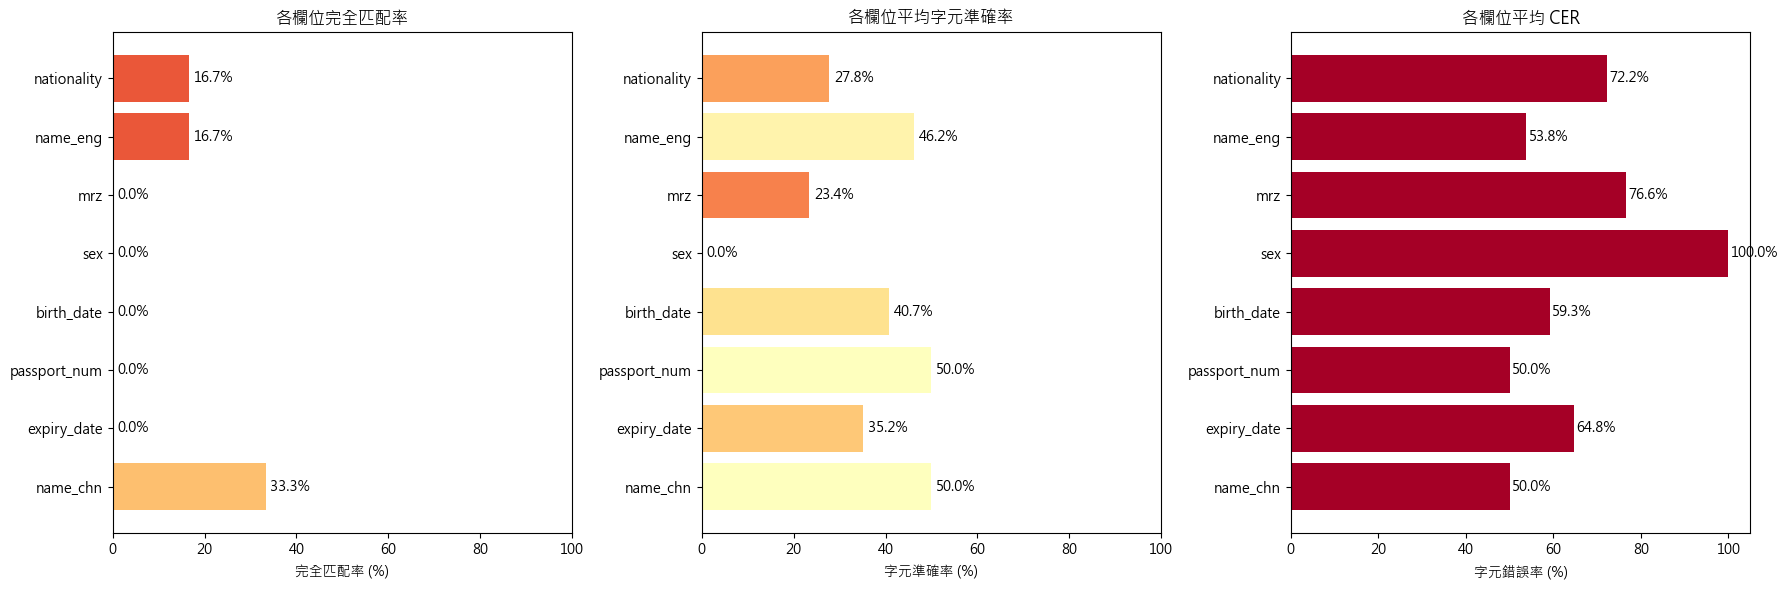

In [97]:
# Cell 6.9: 視覺化 OCR 準確度

if field_stats:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    fields = list(field_stats.keys())
    
    # 1. 完全匹配率
    exact_rates = [field_stats[f]['exact_match_rate'] * 100 for f in fields]
    colors = plt.cm.RdYlGn([r/100 for r in exact_rates])
    axes[0].barh(fields, exact_rates, color=colors)
    axes[0].set_xlabel('完全匹配率 (%)')
    axes[0].set_title('各欄位完全匹配率')
    axes[0].set_xlim(0, 100)
    for i, v in enumerate(exact_rates):
        axes[0].text(v + 1, i, f'{v:.1f}%', va='center')
    
    # 2. 字元準確率
    accuracies = [field_stats[f]['avg_accuracy'] * 100 for f in fields]
    colors = plt.cm.RdYlGn([a/100 for a in accuracies])
    axes[1].barh(fields, accuracies, color=colors)
    axes[1].set_xlabel('字元準確率 (%)')
    axes[1].set_title('各欄位平均字元準確率')
    axes[1].set_xlim(0, 100)
    for i, v in enumerate(accuracies):
        axes[1].text(v + 1, i, f'{v:.1f}%', va='center')
    
    # 3. 字元錯誤率 (CER)
    cers = [field_stats[f]['avg_cer'] * 100 for f in fields]
    colors = plt.cm.RdYlGn_r([c/50 for c in cers])  # 反向色彩（低 CER = 綠色）
    axes[2].barh(fields, cers, color=colors)
    axes[2].set_xlabel('字元錯誤率 (%)')
    axes[2].set_title('各欄位平均 CER')
    for i, v in enumerate(cers):
        axes[2].text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 沒有足夠的資料進行視覺化")

In [99]:
# Cell 6.10: 詳細錯誤分析（顯示 OCR 錯誤案例）

print("🔍 詳細錯誤分析（非完全匹配的案例）")
print("=" * 80)

error_count = 0
for img_eval in all_evaluations:
    for field_name, metrics in img_eval['fields'].items():
        if not metrics['exact_match']:
            error_count += 1
            print(f"\n📸 圖片: {img_eval['image']} | 欄位: {field_name}")
            print(f"   Ground Truth: 「{metrics['ground_truth']}」")
            print(f"   OCR 結果:     「{metrics['ocr_text']}」")
            print(f"   編輯距離: {metrics['edit_distance']} | 字元準確率: {metrics['accuracy']*100:.1f}%")

if error_count == 0:
    print("\n🎉 恭喜！所有 OCR 結果都完全匹配！")
else:
    print(f"\n📊 共發現 {error_count} 個非完全匹配的案例")

🔍 詳細錯誤分析（非完全匹配的案例）

📸 圖片: 100976 | 欄位: name_chn
   Ground Truth: 「吴素媛」
   OCR 結果:     「吴素好」
   編輯距離: 1 | 字元準確率: 66.7%

📸 圖片: 100976 | 欄位: expiry_date
   Ground Truth: 「30JUL2035」
   OCR 結果:     「T9」
   編輯距離: 9 | 字元準確率: 0.0%

📸 圖片: 100976 | 欄位: passport_num
   Ground Truth: 「369123148」
   OCR 結果:     「69123148」
   編輯距離: 1 | 字元準確率: 88.9%

📸 圖片: 100976 | 欄位: birth_date
   Ground Truth: 「16DEC1967」
   OCR 結果:     「DE」
   編輯距離: 7 | 字元準確率: 22.2%

📸 圖片: 100976 | 欄位: sex
   Ground Truth: 「F」
   OCR 結果:     「」
   編輯距離: 1 | 字元準確率: 0.0%

📸 圖片: 100976 | 欄位: mrz
   Ground Truth: 「P<TWNWU<<SU<YUAN<<<<<<<<<<<<<<<<<<<<<<<<<<<<
3691231481TWN6712167F3507304Q220924730<<<<12」
   OCR 結果:     「NDSXS231481TWN6712167F3507304Q22D924730<」
   編輯距離: 53 | 字元準確率: 40.4%

📸 圖片: 100976 | 欄位: name_eng
   Ground Truth: 「WU,SU-YUAN」
   OCR 結果:     「SU-YUAN」
   編輯距離: 3 | 字元準確率: 70.0%

📸 圖片: 100976 | 欄位: nationality
   Ground Truth: 「TWN」
   OCR 結果:     「」
   編輯距離: 3 | 字元準確率: 0.0%

📸 圖片: 112303 | 欄位: name_chn
   Ground Tru

---
## 7. 批次測試與效能分析


In [100]:
# Cell 7.1: 批次處理測試集

print("🔄 批次處理測試集...")

all_results = []
processing_times = []

for img_path in tqdm(test_images_list, desc="處理中"):
    try:
        result = process_passport_image(img_path, best_model, ocr)
        result['image'] = img_path.name
        all_results.append(result)
        processing_times.append(result['inference_time_ms'])
    except Exception as e:
        print(f"⚠️ 處理 {img_path.name} 時發生錯誤: {e}")

print(f"\n✅ 完成處理 {len(all_results)} 張圖片")


🔄 批次處理測試集...


處理中:   0%|          | 0/6 [00:00<?, ?it/s]


✅ 完成處理 6 張圖片


📊 效能統計：
  平均處理時間: 16456.48 ms
  最短處理時間: 15461.22 ms
  最長處理時間: 17565.92 ms
  標準差: 753.49 ms
  平均 FPS: 0.1


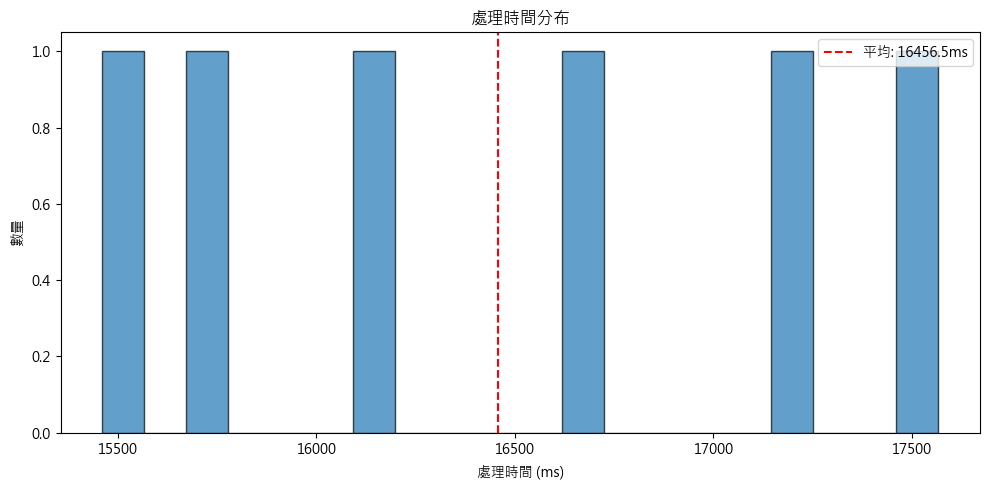

In [101]:
# Cell 7.2: 效能統計

if processing_times:
    print("📊 效能統計：")
    print("="*50)
    print(f"  平均處理時間: {np.mean(processing_times):.2f} ms")
    print(f"  最短處理時間: {np.min(processing_times):.2f} ms")
    print(f"  最長處理時間: {np.max(processing_times):.2f} ms")
    print(f"  標準差: {np.std(processing_times):.2f} ms")
    print(f"  平均 FPS: {1000 / np.mean(processing_times):.1f}")
    
    # 繪製處理時間分布
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(processing_times, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(processing_times), color='red', linestyle='--', 
               label=f'平均: {np.mean(processing_times):.1f}ms')
    ax.set_xlabel('處理時間 (ms)')
    ax.set_ylabel('數量')
    ax.set_title('處理時間分布')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 沒有處理時間資料")


In [102]:
# Cell 7.3: 儲存測試結果

output_json = PROJECT_ROOT / 'test_results.json'

# 準備輸出資料
output_data = {
    'summary': {
        'total_images': len(all_results),
        'avg_processing_time_ms': float(np.mean(processing_times)) if processing_times else 0,
        'model': str(best_model_path),
        'timestamp': datetime.now().isoformat()
    },
    'results': all_results
}

with open(output_json, 'w', encoding='utf-8') as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

print(f"✅ 測試結果已儲存: {output_json}")


✅ 測試結果已儲存: C:\Users\wu020\Documents\Passport-image-recognition\test_results.json


---
## 8. 匯出模型與總結


In [103]:
# Cell 8.1: 匯出為 ONNX 格式（可選）

print("📦 匯出模型為 ONNX 格式...")

try:
    onnx_path = best_model.export(format='onnx', dynamic=True, simplify=True)
    print(f"✅ ONNX 模型已匯出: {onnx_path}")
except Exception as e:
    print(f"⚠️ ONNX 匯出失敗: {e}")


📦 匯出模型為 ONNX 格式...
Ultralytics 8.3.239  Python-3.10.11 torch-2.9.1+cpu CPU (AMD Ryzen 9 5900HS with Radeon Graphics)

PyTorch: starting from 'C:\Users\wu020\Documents\Passport-image-recognition\runs\detect\passport_fields\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 12, 8400) (38.6 MB)

ONNX: starting export with onnx 1.20.0 opset 22...


c:\Users\wu020\Documents\Passport-image-recognition\.venv\lib\site-packages\torch\onnx\_internal\torchscript_exporter\utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.80...
ONNX: export success  8.6s, saved as 'C:\Users\wu020\Documents\Passport-image-recognition\runs\detect\passport_fields\weights\best.onnx' (77.8 MB)

Export complete (9.5s)
Results saved to C:\Users\wu020\Documents\Passport-image-recognition\runs\detect\passport_fields\weights
Predict:         yolo predict task=detect model=C:\Users\wu020\Documents\Passport-image-recognition\runs\detect\passport_fields\weights\best.onnx imgsz=640  
Validate:        yolo val task=detect model=C:\Users\wu020\Documents\Passport-image-recognition\runs\detect\passport_fields\weights\best.onnx imgsz=640 data=C:\Users\wu020\Documents\Passport-image-recognition\dataset\data.yaml  
Visualize:       https://netron.app
✅ ONNX 模型已匯出: C:\Users\wu020\Documents\Passport-image-recognition\runs\detect\passport_fields\weights\best.onnx


In [104]:
# Cell 8.2: 總結

print("\n" + "="*60)
print("🎉 訓練與測試流程完成！")
print("="*60)
print("\n📋 摘要：")
print(f"  - 訓練資料: {len(train_items)} 張")
print(f"  - 驗證資料: {len(val_items)} 張")
print(f"  - 測試資料: {len(test_items)} 張")
print(f"  - 類別數量: {len(CLASS_NAMES)}")
print(f"  - 類別名稱: {CLASS_NAMES}")
print(f"  - 最佳模型: {best_model_path}")
print(f"\n📁 輸出檔案：")
print(f"  - 資料集: {DATASET_DIR}")
print(f"  - 訓練結果: {results_dir}")
print(f"  - 測試結果: {output_json}")
print("\n💡 下一步：")
print("  1. 檢視 test_results.json 分析識別準確度")
print("  2. 如果精度不足，考慮增加訓練資料或調整參數")
print("  3. 將最佳模型整合到 src/ 模組中")
print("  4. 使用 ONNX 模型進行部署優化")



🎉 訓練與測試流程完成！

📋 摘要：
  - 訓練資料: 34 張
  - 驗證資料: 9 張
  - 測試資料: 6 張
  - 類別數量: 8
  - 類別名稱: ['birth_date', 'expiry_date', 'mrz', 'name_chn', 'name_eng', 'nationality', 'passport_num', 'sex']
  - 最佳模型: C:\Users\wu020\Documents\Passport-image-recognition\runs\detect\passport_fields\weights\best.pt

📁 輸出檔案：
  - 資料集: C:\Users\wu020\Documents\Passport-image-recognition\dataset


NameError: name 'results_dir' is not defined

---
## 9. 新增訓練資料（擴充資料集）

此區塊用於將新的 Label Studio 標註資料（`project-瑕疵*.json`）加入訓練集。

### 資料來源
- 標註檔案：專案根目錄下以 `project-` 為首的 JSON 檔案
- 圖片來源：`C:\Users\wu020\OneDrive\桌面\護照資料` 下的各子資料夾


In [105]:
# Cell 9.1: 定義新資料的路徑配置

# 新圖片的根目錄
NEW_IMAGES_ROOT = Path(r"C:\Users\wu020\OneDrive\桌面\護照資料")

# JSON 檔案與對應圖片資料夾的對應關係
# key: JSON 檔案名稱, value: 圖片所在的相對路徑（相對於 NEW_IMAGES_ROOT）
JSON_TO_IMAGE_FOLDER_MAP = {
    "project-瑕疵中.json": [
        "護照圖檔/瑕疵/中文姓名",
    ],
    "project-瑕疵國籍.json": [
        "護照圖檔/瑕疵/國籍",
    ],
    "project-瑕疵英.json": [
        "護照圖檔/瑕疵/英文姓名",
    ],
    "project-瑕疵護照號.json": [
        "護照圖檔/瑕疵/護照號碼",
    ],
    # 如果有其他 JSON 檔案，可以在這裡新增對應
    # "project-XXX.json": ["對應資料夾路徑"],
}

# 全域搜尋路徑（當找不到對應時，會在這些路徑中搜尋）
GLOBAL_IMAGE_SEARCH_PATHS = [
    "護照圖檔/瑕疵/中文姓名",
    "護照圖檔/瑕疵/國籍",
    "護照圖檔/瑕疵/英文姓名",
    "護照圖檔/瑕疵/護照號碼",
    "護照圖檔/成功",
    "護照圖檔/失敗",
    "護照圖檔251118/成功",
    "護照圖檔251118/失敗/MRZ完整",
    "護照圖檔251118/失敗/MRZ不完整",
    "護照圖檔251118/瑕疵",
    "外國護照251113",
]

print("📁 新資料路徑配置完成！")
print(f"📂 新圖片根目錄: {NEW_IMAGES_ROOT}")
print(f"\n📋 已配置 {len(JSON_TO_IMAGE_FOLDER_MAP)} 個 JSON 檔案對應")
for json_file, folders in JSON_TO_IMAGE_FOLDER_MAP.items():
    print(f"  - {json_file} → {folders}")


📁 新資料路徑配置完成！
📂 新圖片根目錄: C:\Users\wu020\OneDrive\桌面\護照資料

📋 已配置 4 個 JSON 檔案對應
  - project-瑕疵中.json → ['護照圖檔/瑕疵/中文姓名']
  - project-瑕疵國籍.json → ['護照圖檔/瑕疵/國籍']
  - project-瑕疵英.json → ['護照圖檔/瑕疵/英文姓名']
  - project-瑕疵護照號.json → ['護照圖檔/瑕疵/護照號碼']


In [106]:
# Cell 9.2: 定義圖片搜尋與 ID 提取函數

def extract_image_filename_from_item(item):
    """
    從 Label Studio 項目中提取圖片檔名。
    
    Label Studio 的圖片路徑格式可能為：
    - /data/upload/8/7618f229-171552O.jpg
    - /data/upload/2/a744d314-46183.jpg
    
    Args:
        item: Label Studio 標註項目
    
    Returns:
        tuple: (完整檔名, 簡化 ID)
            - 完整檔名: 如 "171552O.jpg" 或 "46183.jpg"
            - 簡化 ID: 如 "171552O" 或 "46183"（不含副檔名）
    
    Examples:
        >>> filename, img_id = extract_image_filename_from_item(item)
        >>> print(filename)  # "171552O.jpg"
        >>> print(img_id)    # "171552O"
    
    Raises:
        此函數不會拋出錯誤，若無法提取則返回 (None, None)
    """
    # 嘗試從 data.ocr 或其他欄位提取
    if 'data' in item:
        data = item['data']
        for key in ['ocr', 'image', 'img']:
            if key in data:
                path = str(data[key])
                # 提取 UUID-數字ID.jpg 格式的檔名
                # 例如: /data/upload/8/7618f229-171552O.jpg → 171552O.jpg
                match = re.search(r'[a-f0-9]+-(\d+O?)\.jpg', path)
                if match:
                    img_id = match.group(1)
                    filename = f"{img_id}.jpg"
                    return filename, img_id
                
                # 嘗試直接提取數字.jpg 格式
                match = re.search(r'(\d+)\.jpg', path)
                if match:
                    img_id = match.group(1)
                    filename = f"{img_id}.jpg"
                    return filename, img_id
    
    # 從 file_upload 欄位提取
    if 'file_upload' in item:
        file_upload = item['file_upload']
        match = re.search(r'[a-f0-9]+-(\d+O?)\.jpg', file_upload)
        if match:
            img_id = match.group(1)
            filename = f"{img_id}.jpg"
            return filename, img_id
    
    return None, None


def find_image_in_paths(filename, search_paths, root_dir):
    """
    在多個路徑中搜尋圖片檔案。
    
    Args:
        filename: 要搜尋的檔名（如 "171552O.jpg"）
        search_paths: 搜尋路徑列表（相對於 root_dir）
        root_dir: 根目錄 Path 物件
    
    Returns:
        Path 或 None: 找到的圖片完整路徑，若找不到則返回 None
    
    Examples:
        >>> path = find_image_in_paths("171552O.jpg", ["護照圖檔/瑕疵/國籍"], root)
        >>> print(path)
        "C:/Users/.../護照圖檔/瑕疵/國籍/171552O.jpg"
    
    Raises:
        此函數不會拋出錯誤
    """
    for search_path in search_paths:
        full_path = root_dir / search_path / filename
        if full_path.exists():
            return full_path
    return None


def build_image_index(root_dir, search_paths):
    """
    建立圖片檔名到完整路徑的索引。
    
    Args:
        root_dir: 根目錄 Path 物件
        search_paths: 搜尋路徑列表
    
    Returns:
        dict: {檔名: 完整路徑} 的對應字典
    
    Examples:
        >>> index = build_image_index(root, ["護照圖檔/瑕疵/國籍"])
        >>> print(index["171552O.jpg"])
    
    Raises:
        此函數不會拋出錯誤
    """
    image_index = {}
    
    for search_path in search_paths:
        folder = root_dir / search_path
        if not folder.exists():
            continue
        
        for ext in ['*.jpg', '*.jpeg', '*.png']:
            for img_path in folder.glob(ext):
                image_index[img_path.name] = img_path
    
    return image_index


print("✅ 圖片搜尋函數定義完成")


✅ 圖片搜尋函數定義完成


In [107]:
# Cell 9.3: 載入所有新的 JSON 標註檔案

def load_label_studio_json(json_path):
    """
    載入 Label Studio JSON 檔案。
    
    Args:
        json_path: JSON 檔案路徑
    
    Returns:
        list: Label Studio 標註資料列表
    
    Examples:
        >>> data = load_label_studio_json("project-V1.json")
        >>> print(len(data))
    
    Raises:
        FileNotFoundError: 當檔案不存在時
        json.JSONDecodeError: 當 JSON 格式錯誤時
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        raw_content = f.read()
        # Label Studio 匯出的 JSON 開頭可能有額外的數字（project ID）
        json_start = raw_content.find('[')
        if json_start > 0:
            raw_content = raw_content[json_start:]
        return json.loads(raw_content)


print("⏳ 載入所有新的 JSON 標註檔案...")

# 找出所有以 project- 開頭的 JSON 檔案（排除 V1）
all_project_jsons = list(PROJECT_ROOT.glob("project-*.json"))
new_json_files = [f for f in all_project_jsons if f.name != "project-V1.json"]

print(f"\n📁 找到 {len(new_json_files)} 個新的 JSON 檔案：")
for json_file in new_json_files:
    print(f"  - {json_file.name}")

# 載入所有新資料
all_new_data = {}
for json_file in new_json_files:
    try:
        data = load_label_studio_json(json_file)
        all_new_data[json_file.name] = data
        print(f"  ✅ {json_file.name}: {len(data)} 筆標註")
    except json.JSONDecodeError as e:
        print(f"  ❌ {json_file.name}: JSON 解析錯誤 - {e}")
    except FileNotFoundError as e:
        print(f"  ❌ {json_file.name}: 檔案不存在 - {e}")

total_new_annotations = sum(len(data) for data in all_new_data.values())
print(f"\n📊 總共載入 {total_new_annotations} 筆新標註資料")


⏳ 載入所有新的 JSON 標註檔案...

📁 找到 5 個新的 JSON 檔案：
  - project-sucess-all.json
  - project-瑕疵中.json
  - project-瑕疵國籍.json
  - project-瑕疵英.json
  - project-瑕疵護照號.json
  ✅ project-sucess-all.json: 89 筆標註
  ✅ project-瑕疵中.json: 49 筆標註
  ✅ project-瑕疵國籍.json: 11 筆標註
  ✅ project-瑕疵英.json: 8 筆標註
  ✅ project-瑕疵護照號.json: 29 筆標註

📊 總共載入 186 筆新標註資料


In [108]:
# Cell 9.4: 建立圖片索引並匹配標註與圖片

print("⏳ 建立圖片索引...")

# 建立全域圖片索引
image_index = build_image_index(NEW_IMAGES_ROOT, GLOBAL_IMAGE_SEARCH_PATHS)
print(f"✅ 已索引 {len(image_index)} 張圖片")

# 統計各類別的標籤數量（從新資料中）
new_label_counts = Counter()

# 處理每個 JSON 檔案，匹配圖片路徑
matched_items = []
unmatched_items = []

for json_name, items in all_new_data.items():
    print(f"\n📋 處理 {json_name}...")
    
    # 取得對應的搜尋路徑
    search_paths = JSON_TO_IMAGE_FOLDER_MAP.get(json_name, [])
    
    for item in items:
        filename, img_id = extract_image_filename_from_item(item)
        
        if filename is None:
            unmatched_items.append({
                'json': json_name,
                'item_id': item.get('id'),
                'reason': '無法提取圖片檔名'
            })
            continue
        
        # 先在指定路徑搜尋
        img_path = find_image_in_paths(filename, search_paths, NEW_IMAGES_ROOT)
        
        # 若找不到，在全域索引中搜尋
        if img_path is None and filename in image_index:
            img_path = image_index[filename]
        
        if img_path is None:
            unmatched_items.append({
                'json': json_name,
                'item_id': item.get('id'),
                'filename': filename,
                'reason': '找不到圖片檔案'
            })
            continue
        
        # 統計標籤
        if 'annotations' in item and item['annotations']:
            for anno in item['annotations']:
                for result in anno.get('result', []):
                    if result.get('type') == 'labels' and 'value' in result:
                        labels = result['value'].get('labels', [])
                        for label in labels:
                            new_label_counts[label] += 1
        
        matched_items.append({
            'json': json_name,
            'item': item,
            'img_path': img_path,
            'img_id': img_id
        })

print(f"\n📊 匹配結果：")
print(f"  ✅ 成功匹配: {len(matched_items)} 筆")
print(f"  ❌ 未匹配: {len(unmatched_items)} 筆")

if unmatched_items[:5]:
    print(f"\n⚠️ 前 5 筆未匹配的項目：")
    for item in unmatched_items[:5]:
        print(f"  - {item}")


⏳ 建立圖片索引...
✅ 已索引 775 張圖片

📋 處理 project-sucess-all.json...

📋 處理 project-瑕疵中.json...

📋 處理 project-瑕疵國籍.json...

📋 處理 project-瑕疵英.json...

📋 處理 project-瑕疵護照號.json...

📊 匹配結果：
  ✅ 成功匹配: 186 筆
  ❌ 未匹配: 0 筆


In [109]:
# Cell 9.5: 分析新資料的標籤並更新類別對應表

print("📊 新資料的標籤統計：")
print("="*50)
for label, count in sorted(new_label_counts.items(), key=lambda x: -x[1]):
    print(f"  {label}: {count} 個")

# 檢查是否有新的標籤類型
existing_labels = set(CLASS_NAMES)
new_labels = set(new_label_counts.keys()) - existing_labels

if new_labels:
    print(f"\n⚠️ 發現 {len(new_labels)} 個新的標籤類型：")
    for label in new_labels:
        print(f"  - {label}")
    
    # 更新類別名稱和對應表
    UPDATED_CLASS_NAMES = sorted(existing_labels | new_labels)
    UPDATED_CLASS_TO_ID = {name: idx for idx, name in enumerate(UPDATED_CLASS_NAMES)}
    
    print(f"\n📦 更新後的類別對應表：")
    for name, idx in UPDATED_CLASS_TO_ID.items():
        marker = "🆕" if name in new_labels else "  "
        print(f"  {marker} {idx}: {name}")
else:
    UPDATED_CLASS_NAMES = CLASS_NAMES
    UPDATED_CLASS_TO_ID = CLASS_TO_ID
    print(f"\n✅ 沒有新的標籤類型，使用現有的類別對應表")

print(f"\n📋 類別總數: {len(UPDATED_CLASS_NAMES)}")


📊 新資料的標籤統計：
  name_chn: 186 個
  name_eng: 186 個
  nationality: 186 個
  sex: 186 個
  birth_date: 186 個
  expiry_date: 186 個
  mrz: 186 個
  passport_num: 186 個

✅ 沒有新的標籤類型，使用現有的類別對應表

📋 類別總數: 8


In [110]:
# Cell 9.6: 將新資料轉換為 YOLO 格式並加入資料集

# 設定新資料的分割比例
NEW_DATA_TRAIN_RATIO = 0.8
NEW_DATA_VAL_RATIO = 0.2

print(f"📊 新資料分割比例: Train={NEW_DATA_TRAIN_RATIO}, Val={NEW_DATA_VAL_RATIO}")

# 準備新資料
new_valid_items = []

for matched in tqdm(matched_items, desc="轉換 YOLO 格式"):
    item = matched['item']
    img_path = matched['img_path']
    img_id = matched['img_id']
    
    # 轉換為 YOLO 格式
    yolo_lines = convert_to_yolo_format(item, UPDATED_CLASS_TO_ID)
    
    if yolo_lines:  # 只保留有標註的項目
        new_valid_items.append({
            'img_id': img_id,
            'img_path': img_path,
            'yolo_lines': yolo_lines,
            'source': matched['json']
        })

print(f"\n📋 有效的新資料: {len(new_valid_items)} 筆")

# 隨機打亂
random.seed(42)
random.shuffle(new_valid_items)

# 計算分割點
n_new_total = len(new_valid_items)
n_new_train = int(n_new_total * NEW_DATA_TRAIN_RATIO)

new_train_items = new_valid_items[:n_new_train]
new_val_items = new_valid_items[n_new_train:]

print(f"\n📊 新資料分割結果：")
print(f"  新增 Train: {len(new_train_items)} 張")
print(f"  新增 Val: {len(new_val_items)} 張")


📊 新資料分割比例: Train=0.8, Val=0.2


轉換 YOLO 格式:   0%|          | 0/186 [00:00<?, ?it/s]


📋 有效的新資料: 186 筆

📊 新資料分割結果：
  新增 Train: 148 張
  新增 Val: 38 張


In [111]:
# Cell 9.7: 複製新圖片並產生標籤檔案

def add_new_data_to_dataset(items, split_name, dataset_dir, use_original_filename=True):
    """
    將新資料加入 YOLO 資料集。
    
    Args:
        items: 資料項目列表
        split_name: 分割名稱 (train/val/test)
        dataset_dir: 資料集目錄
        use_original_filename: 是否使用原始檔名（避免衝突時會加上後綴）
    
    Returns:
        dict: 包含成功和失敗數量的統計
    
    Examples:
        >>> stats = add_new_data_to_dataset(new_train_items, 'train', DATASET_DIR)
        >>> print(stats['success'])
    
    Raises:
        此函數不會拋出錯誤，個別檔案的錯誤會被記錄
    """
    images_dst = dataset_dir / "images" / split_name
    labels_dst = dataset_dir / "labels" / split_name
    
    stats = {'success': 0, 'skipped': 0, 'error': 0}
    
    for item in tqdm(items, desc=f"處理 {split_name}"):
        img_id = item['img_id']
        src_path = item['img_path']
        
        # 決定目標檔名（處理可能的檔名衝突）
        base_name = img_id
        dst_img_path = images_dst / f"{base_name}.jpg"
        dst_label_path = labels_dst / f"{base_name}.txt"
        
        # 如果檔案已存在，添加後綴
        counter = 1
        while dst_img_path.exists() or dst_label_path.exists():
            base_name = f"{img_id}_{counter}"
            dst_img_path = images_dst / f"{base_name}.jpg"
            dst_label_path = labels_dst / f"{base_name}.txt"
            counter += 1
        
        try:
            # 複製圖片
            shutil.copy2(src_path, dst_img_path)
            
            # 產生標籤檔
            with open(dst_label_path, 'w', encoding='utf-8') as f:
                f.write('\n'.join(item['yolo_lines']))
            
            stats['success'] += 1
            
        except FileNotFoundError as e:
            print(f"⚠️ 找不到來源檔案: {src_path}")
            stats['error'] += 1
        except PermissionError as e:
            print(f"⚠️ 權限錯誤: {e}")
            stats['error'] += 1
    
    return stats


print("⏳ 開始將新資料加入資料集...")

# 加入新的訓練資料
train_stats = add_new_data_to_dataset(new_train_items, 'train', DATASET_DIR)
print(f"\n✅ Train: 成功 {train_stats['success']} 張, 錯誤 {train_stats['error']} 張")

# 加入新的驗證資料
val_stats = add_new_data_to_dataset(new_val_items, 'val', DATASET_DIR)
print(f"✅ Val: 成功 {val_stats['success']} 張, 錯誤 {val_stats['error']} 張")

print("\n✅ 新資料加入完成！")


⏳ 開始將新資料加入資料集...


處理 train:   0%|          | 0/148 [00:00<?, ?it/s]


✅ Train: 成功 148 張, 錯誤 0 張


處理 val:   0%|          | 0/38 [00:00<?, ?it/s]

✅ Val: 成功 38 張, 錯誤 0 張

✅ 新資料加入完成！


In [112]:
# Cell 9.8: 更新 data.yaml（如果有新類別）

# 如果類別有更新，需要重新產生 data.yaml
if new_labels:
    print("⏳ 更新 data.yaml（因為有新的類別）...")
    
    updated_data_yaml = {
        'path': str(DATASET_DIR.resolve()),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'nc': len(UPDATED_CLASS_NAMES),
        'names': {i: name for i, name in enumerate(UPDATED_CLASS_NAMES)}
    }
    
    yaml_path = DATASET_DIR / 'data.yaml'
    with open(yaml_path, 'w', encoding='utf-8') as f:
        yaml.dump(updated_data_yaml, f, default_flow_style=False, allow_unicode=True)
    
    print(f"✅ data.yaml 已更新！")
    print(f"\n📋 更新後的內容：")
    print("="*50)
    with open(yaml_path, 'r', encoding='utf-8') as f:
        print(f.read())
else:
    print("✅ 類別沒有變化，data.yaml 不需更新")


✅ 類別沒有變化，data.yaml 不需更新


In [113]:
# Cell 9.9: 驗證更新後的資料集

print("🔍 驗證更新後的資料集...")

for split in ['train', 'val', 'test']:
    images = list((DATASET_DIR / 'images' / split).glob('*.jpg'))
    labels = list((DATASET_DIR / 'labels' / split).glob('*.txt'))
    
    print(f"\n{split}:")
    print(f"  圖片數量: {len(images)}")
    print(f"  標籤數量: {len(labels)}")
    
    # 檢查是否每張圖片都有對應的標籤
    image_stems = set(img.stem for img in images)
    label_stems = set(lbl.stem for lbl in labels)
    
    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems
    
    if missing_labels:
        print(f"  ⚠️ 缺少標籤: {len(missing_labels)} 張")
    if missing_images:
        print(f"  ⚠️ 缺少圖片: {len(missing_images)} 張")
    if not missing_labels and not missing_images:
        print(f"  ✅ 圖片與標籤完全匹配")

# 統計總資料量
total_images = sum(
    len(list((DATASET_DIR / 'images' / split).glob('*.jpg')))
    for split in ['train', 'val', 'test']
)
print(f"\n📊 資料集總計: {total_images} 張圖片")
print("✅ 資料集驗證完成！")


🔍 驗證更新後的資料集...

train:
  圖片數量: 259
  標籤數量: 259
  ✅ 圖片與標籤完全匹配

val:
  圖片數量: 67
  標籤數量: 67
  ✅ 圖片與標籤完全匹配

test:
  圖片數量: 6
  標籤數量: 6
  ✅ 圖片與標籤完全匹配

📊 資料集總計: 332 張圖片
✅ 資料集驗證完成！


In [114]:
# Cell 9.10: 新增資料總結

print("\n" + "="*60)
print("🎉 新增資料流程完成！")
print("="*60)

print(f"\n📋 新增資料摘要：")
print(f"  - 載入的 JSON 檔案: {len(all_new_data)} 個")
print(f"  - 成功匹配的標註: {len(matched_items)} 筆")
print(f"  - 新增至 Train: {train_stats['success']} 張")
print(f"  - 新增至 Val: {val_stats['success']} 張")

if new_labels:
    print(f"  - 新增的類別: {new_labels}")
    print(f"  - 更新後類別總數: {len(UPDATED_CLASS_NAMES)}")

print("\n💡 下一步：")
print("  1. 回到 Cell 4.2 設定訓練參數")
print("  2. 執行 Cell 4.3 開始重新訓練模型")
print("  3. 如果有新類別，模型需要從頭訓練（不使用舊權重）")
print("\n⚠️ 注意事項：")
print("  - 如果要增量訓練，可以載入之前的 best.pt 作為基礎")
print("  - 如果有新類別，建議使用預訓練的 yolo11m.pt 重新訓練")
print("  - 刪除 dataset/labels/*.cache 檔案以重建快取")



🎉 新增資料流程完成！

📋 新增資料摘要：
  - 載入的 JSON 檔案: 5 個
  - 成功匹配的標註: 186 筆
  - 新增至 Train: 148 張
  - 新增至 Val: 38 張

💡 下一步：
  1. 回到 Cell 4.2 設定訓練參數
  2. 執行 Cell 4.3 開始重新訓練模型
  3. 如果有新類別，模型需要從頭訓練（不使用舊權重）

⚠️ 注意事項：
  - 如果要增量訓練，可以載入之前的 best.pt 作為基礎
  - 如果有新類別，建議使用預訓練的 yolo11m.pt 重新訓練
  - 刪除 dataset/labels/*.cache 檔案以重建快取


### 如何新增更多資料

當您有新的 Label Studio JSON 檔案和對應圖片時，請按照以下步驟操作：

#### 步驟 1: 準備資料
1. 將 Label Studio 匯出的 JSON 檔案放到專案根目錄（以 `project-` 為首命名）
2. 將對應的圖片放到 `C:\Users\wu020\OneDrive\桌面\護照資料` 下的適當資料夾

#### 步驟 2: 更新路徑配置
在 **Cell 9.1** 中更新 `JSON_TO_IMAGE_FOLDER_MAP`：

```python
JSON_TO_IMAGE_FOLDER_MAP = {
    "project-瑕疵中.json": ["護照圖檔/瑕疵/中文姓名"],
    "project-新檔案.json": ["新資料夾路徑"],  # 新增這行
}
```

#### 步驟 3: 執行新增流程
依序執行 Cell 9.1 ~ 9.10

#### 步驟 4: 重新訓練模型
執行 Cell 4.2 ~ 4.3 開始訓練
